In [1]:
import tensorflow as tf
print(tf.__version__)


2.13.0


In [2]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Thu Dec 11 00:22:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 561.09                 Driver Version: 561.09         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080      WDDM  |   00000000:0A:00.0  On |                  N/A |
|  0%   35C    P8             19W /  370W |    2223MiB /  10240MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# !pip install boruta
# !pip install smote_variants
# !pip install lime
# !pip install signaturizer

In [4]:
#import default and other essential libraries
import os
import numpy as np
import pandas as pd
import sklearn
import joblib
import pickle
import csv
import sys
import random
import seaborn as sns
from functools import reduce
import matplotlib.backends.backend_pdf
import matplotlib.pyplot as plt
import tensorflow as tf

In [5]:
#Packages to split data and other preprocessing
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn import metrics
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.decomposition import PCA
from boruta import BorutaPy
from imblearn.pipeline import Pipeline as sample_pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE

In [6]:
#Import Classifiers
from sklearn import svm
import smote_variants as sv
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

In [7]:
## Package for calculating accuracy and analysis
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.manifold import TSNE
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import roc_curve, auc, accuracy_score, roc_auc_score, cohen_kappa_score, f1_score, precision_score, recall_score, matthews_corrcoef
from sklearn.model_selection import StratifiedKFold
from lime.lime_tabular import LimeTabularExplainer

In [8]:
from signaturizer import Signaturizer
from tqdm import tqdm

In [9]:
def handle_missing_values(data):
    print('Handling missing values')
    data = data.replace([np.inf, -np.inf, "", " "], np.nan)
    data = data.replace(["", " "], np.nan)
    for i in data.columns:
        data[i] = data[i].fillna(data[i].mean())
    return data

def Feature_Signaturizer(dat):
    sig_df=pd.DataFrame()
    desc=['A','B','C','D','E']
    for dsc in tqdm(desc):
        for i in range(1,6):
            sign = Signaturizer(dsc+str(i), local=True)
            results = sign.predict(dat)
            df=pd.DataFrame(results.signature)
            for clm in list(df.columns):
                df=df.rename(columns={clm:dsc+str(i)+'_'+str(clm)})
            sig_df=pd.concat([sig_df,df],axis = 1)
    sig_df = handle_missing_values(sig_df)
    res = pd.DataFrame()
    res['smiles'] = dat
    res = pd.concat([res,sig_df],axis = 1)
    return res

In [10]:
# 指定当前的工作文件夹
import os
# 此处为google drive中的文件路径,drive为之前指定的工作根目录，要加上
os.chdir("C:/Users/Zz/Desktop/致癌性课题/00. 机器学习相关内容/zhuhao")
#load preprocessed feature file here
data = pd.read_csv(r'AID_1259411_datatable_all.csv') ### features in columns,molecules in rows
# 1. 根据列名为 PUBCHEM_CID 的取值去除重复的
data = data.drop_duplicates(subset='PUBCHEM_CID')

# 2. 替换 PUBCHEM_ACTIVITY_OUTCOME 列的取值
data['PUBCHEM_ACTIVITY_OUTCOME'] = data['PUBCHEM_ACTIVITY_OUTCOME'].replace({
    'Active': 1,
    'Inactive': 0,
    'Unspecified': np.nan
})

# 将 'Status' 列名修改为 'status'
data = data.rename(columns={'PUBCHEM_ACTIVITY_OUTCOME': 'status'})

# 3. 删除 SMILES 和 PUBCHEM_ACTIVITY_OUTCOME 两列中任一有空值的行
data = data.dropna(subset=['SMILES', 'status'])

# 4. 重新设置索引
data.reset_index(drop=True, inplace=True)

# 输出处理后的数据
data

,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,SMILES,status
0,1,363897951,5897.0,CC(=O)NC1=CC2=C(C=C1)C3=CC=CC=C3C2,1.0
1,42,363897952,178.0,CC(=O)N,1.0
2,43,363897953,1983.0,CC(=O)NC1=CC=C(C=C1)O,1.0
3,53,363897954,1989.0,CC(=O)C1=CC=C(C=C1)S(=O)(=O)NC(=O)NC2CCCCC2,0.0
4,57,363897955,67180.0,CC(=NO)C,1.0
...,...,...,...,...,...
1640,7262,363907507,62067.0,CC1=CC(=C(C=C1NC(=O)C)NS(=O)(=O)C(F)(F)F)C.C(C...,0.0
1641,7264,363907508,62781.0,C[N+]1(CCCCC1)C.[Cl-],0.0
1642,7266,363907509,11409499.0,COC1=CC(=NC(=N1)NC(=O)NS(=O)(=O)C2=C(C=CC(=C2)...,0.0
1643,7270,363907510,35823.0,C1=CC(=C(C=C1C2=CC(=C(C=C2Cl)Cl)Cl)Cl)Cl,1.0


In [11]:
# 提取 SMILES 列
data_smiles = data['SMILES']
# 使用 Feature_Signaturizer 计算特征
data_features = Feature_Signaturizer(data_smiles)

  0%|                                                                                            | 0/5 [00:00<?, ?it/s]
Parsing SMILES: 0it [00:00, ?it/s]
Parsing SMILES: 795it [00:00, 7948.21it/s]
Parsing SMILES: 1645it [00:00, 7028.32it/s]

Generating signatures:   0%|                                                                    | 0/13 [00:00<?, ?it/s]

1/1 [==============================] - 0s 54ms/step



Generating signatures:   8%|████▌                                                       | 1/13 [00:00<00:05,  2.38it/s]

1/1 [==============================] - 0s 23ms/step



Generating signatures:  15%|█████████▏                                                  | 2/13 [00:00<00:03,  2.99it/s]

...

1/1 [==============================] - 0s 22ms/step



Generating signatures:  92%|██████████████████████████████████████████████████████▍    | 12/13 [00:03<00:00,  3.11it/s]

1/1 [==============================] - 0s 50ms/step



100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [02:09<00:00, 25.84s/it]

Handling missing values


In [12]:
# 保留原始的 'status' 列
data = pd.concat([data_features, data['status']], axis=1)
data.to_csv('data_1259411.csv')
# 打印查看结果
print(data)

                                                 smiles      A1_0      A1_1  \
0                    CC(=O)NC1=CC2=C(C=C1)C3=CC=CC=C3C2 -0.100804  0.096188   
1                                               CC(=O)N -0.096465  0.053733   
2                                 CC(=O)NC1=CC=C(C=C1)O -0.094766  0.099283   
3           CC(=O)C1=CC=C(C=C1)S(=O)(=O)NC(=O)NC2CCCCC2  0.082643  0.102964   
4                                              CC(=NO)C -0.096225  0.070780   
...                                                 ...       ...       ...   
1640  CC1=CC(=C(C=C1NC(=O)C)NS(=O)(=O)C(F)(F)F)C.C(C...  0.100697  0.100913   
1641                              C[N+]1(CCCCC1)C.[Cl-] -0.094283 -0.093734   
1642  COC1=CC(=NC(=N1)NC(=O)NS(=O)(=O)C2=C(C=CC(=C2)...  0.087757  0.102687   
1643           C1=CC(=C(C=C1C2=CC(=C(C=C2Cl)Cl)Cl)Cl)Cl -0.100705 -0.096396   
1644  C1=CC(=CC(=C1)C(F)(F)F)/C(=N/NC(=O)NC2=CC=C(C=... -0.095451  0.019041   

          A1_2      A1_3      A1_4      A1_5      A

In [14]:
# dropping ALL duplicate values, if any
data.drop_duplicates(subset ="smiles", keep = 'first', inplace = True, ignore_index = True)
data

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
0,CC(=O)NC1=CC2=C(C=C1)C3=CC=CC=C3C2,-0.100800,0.096205,-0.101666,0.013622,0.045533,0.103638,0.100818,-0.085028,-0.027932,...,0.077215,-0.060099,0.000407,0.024521,-0.008713,0.052200,0.073152,-0.119952,0.076824,1.0
1,CC(=O)N,-0.096464,0.053822,-0.087383,0.095549,-0.091416,0.096470,0.096480,-0.096477,-0.077987,...,-0.118487,-0.006075,0.104476,0.081948,-0.120817,-0.001020,-0.131218,0.095820,-0.004740,1.0
2,CC(=O)NC1=CC=C(C=C1)O,-0.094767,0.099285,-0.069983,0.078858,0.014583,0.099227,0.099023,-0.099302,-0.096730,...,0.043367,-0.080618,0.056817,0.146075,0.018187,-0.044958,0.020963,0.084850,0.095499,1.0
3,CC(=O)C1=CC=C(C=C1)S(=O)(=O)NC(=O)NC2CCCCC2,0.082662,0.102963,0.096697,0.088996,0.102963,0.102961,0.098535,-0.102962,-0.102963,...,0.040878,-0.093784,0.035378,-0.097579,0.009945,-0.008528,-0.013349,-0.078162,-0.111090,0.0
4,CC(=NO)C,-0.096225,0.070796,0.064892,0.091473,-0.093061,0.077097,0.088396,-0.096911,-0.096889,...,-0.055854,0.063072,0.029263,0.087089,0.052258,0.060351,-0.020115,0.083724,0.063224,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1640,CC1=CC(=C(C=C1NC(=O)C)NS(=O)(=O)C(F)(F)F)C.C(C...,0.100701,0.100916,-0.074545,0.100947,0.100983,0.100974,-0.099876,-0.100985,-0.100985,...,-0.037687,-0.037889,0.077509,0.004429,-0.126974,-0.104519,-0.128836,-0.138834,0.074467,0.0
1641,C[N+]1(CCCCC1)C.[Cl-],-0.094284,-0.093734,-0.093366,-0.093898,-0.094284,0.082861,0.094284,-0.055373,0.065112,...,-0.008070,0.049642,-0.096573,0.016450,-0.077732,0.119295,0.136613,0.142595,0.075937,0.0
1642,COC1=CC(=NC(=N1)NC(=O)NS(=O)(=O)C2=C(C=CC(=C2)...,0.087762,0.102691,-0.080387,0.104354,0.104394,0.104216,-0.094918,-0.104398,-0.104403,...,0.013931,0.066649,0.075433,0.087392,0.006906,-0.104028,-0.127244,0.015713,0.102034,0.0
1643,C1=CC(=C(C=C1C2=CC(=C(C=C2Cl)Cl)Cl)Cl)Cl,-0.100700,-0.096396,-0.103261,-0.039456,-0.090105,0.103162,0.103213,0.018000,0.081154,...,-0.084086,-0.101899,-0.091386,-0.104063,0.063007,0.121405,-0.042903,-0.044005,-0.042278,1.0


In [15]:
def Boruta_Filteration(X_train,y_train,X_test,y_test):
    #### making files for boruta
    features = [f for f in X_train.columns if f not in ['status']]
    X_train_boruta = X_train[features].values
    Y_train_boruta = y_train.values.ravel()
    X_test_boruta = X_test[features].values
    Y_test_boruta = y_test.values.ravel()

    print('Before filteration\nTrain shape\n',X_train_boruta.shape,'\nTest shape\n',X_test_boruta.shape)

    ### implementing boruta

    # define random forest classifier, with utilising all cores and
    # sampling in proportion to y labels
    rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5)

    # define Boruta feature selection method
    feat_selector = BorutaPy(rf, n_estimators=100, random_state=1)

    # find all relevant features - 5 features should be selected
    feat_selector.fit(X_train_boruta, Y_train_boruta)

    # check selected features - first 5 features are selected
    feat_selector.support_

    # check ranking of features
    feat_selector.ranking_

    # call transform() on X to filter it down to selected features
    X_train_filtered = feat_selector.transform(X_train_boruta)
    X_test_filtered = feat_selector.transform(X_test_boruta)

    ### name of the features selected####
    final_features = list()
    indexes = np.where(feat_selector.support_ == True)
    for x in np.nditer(indexes):
        final_features.append(features[x])

    print('# of Features selected:',len(final_features))

    X_train_filtered=pd.DataFrame(X_train_filtered,columns=final_features)
    X_test_filtered=pd.DataFrame(X_test_filtered,columns=final_features)

    print('After filteration\nTrain shape\n',X_train_filtered.shape,'\nTest shape\n',X_test_filtered.shape)

    return X_train_filtered,X_test_filtered,Y_train_boruta,Y_test_boruta,final_features

In [16]:
'''
def TSNE_plot(data,data_labels):
        tsne = TSNE(n_components=2, random_state=50)
        transformed_data = tsne.fit_transform(data)
        k = np.array(transformed_data)
        Group=["Class 0","Class 1"]
        plt.scatter(k[:, 0],k[:, 1], c=data_labels)
        #plt.legend(loc="lower right")
        plt.show()
'''

'\ndef TSNE_plot(data,data_labels):\n        tsne = TSNE(n_components=2, random_state=50)\n        transformed_data = tsne.fit_transform(data)\n        k = np.array(transformed_data)\n        Group=["Class 0","Class 1"]\n        plt.scatter(k[:, 0],k[:, 1], c=data_labels)\n        #plt.legend(loc="lower right")\n        plt.show()\n'

In [26]:
def Smote(traindata,trainlabel,prop):
        oversampler= sv.MSMOTE(proportion=prop,random_state=50)
        X_samp, y_samp= oversampler.sample(traindata.values,trainlabel.values)     
        TSNE_plot(X_samp, y_samp)
        X_samp= pd.DataFrame(X_samp)
        y_samp=pd.DataFrame(y_samp)
        X_samp.columns =list(traindata.columns.values)
        return X_samp,y_samp
def TSNE_plot(data,data_labels):
        tsne = TSNE(n_components=2, random_state=50)
        transformed_data = tsne.fit_transform(data)
        k = np.array(transformed_data)
        Group=["Class 0","Class 1"]
        plt.scatter(k[:, 0],k[:, 1], c=data_labels)
        plt.legend(loc="lower right")
        plt.show()

In [18]:
'''
from imblearn.under_sampling import RandomUnderSampler
def Smote(traindata,trainlabel):
        # define undersample strategy
        undersample = RandomUnderSampler(sampling_strategy='majority')
        # fit and apply the transform
        X_samp, y_samp = undersample.fit_resample(traindata.values,trainlabel.values)        
        TSNE_plot(X_samp, y_samp)
        X_samp= pd.DataFrame(X_samp)
        y_samp=pd.DataFrame(y_samp)
        X_samp.columns =list(traindata.columns.values)
        return X_samp,y_samp
def TSNE_plot(data,data_labels):
        tsne = TSNE(n_components=2, random_state=50)
        transformed_data = tsne.fit_transform(data)
        k = np.array(transformed_data)
        Group=["Class 0","Class 1"]
        plt.scatter(k[:, 0],k[:, 1], c=data_labels)
        plt.legend(loc="lower right")
        plt.show()
'''

In [19]:
# Set random seed to maintain the randomness of each hyperparameter tuning run
def seed_all():
    np.random.seed(123)
    tf.random.set_seed(123)
seed_all()

In [20]:
# Make a new directory for HyperParameter Tuning
os.mkdir('AID_1259411')

In [27]:
# FROM = Path of directory from which to load the preprocessed signaturizer file
FROM='C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao'
# TO = Path of the newly made HyperParameter Tuning directory
TO='C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao/AID_1259411/'

# Set the HPTuning directory as the current working directory
os.chdir(TO)

In [28]:
Data=data.dropna()
Data

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
0,CC(=O)NC1=CC2=C(C=C1)C3=CC=CC=C3C2,-0.100800,0.096205,-0.101666,0.013622,0.045533,0.103638,0.100818,-0.085028,-0.027932,...,0.077215,-0.060099,0.000407,0.024521,-0.008713,0.052200,0.073152,-0.119952,0.076824,1.0
1,CC(=O)N,-0.096464,0.053822,-0.087383,0.095549,-0.091416,0.096470,0.096480,-0.096477,-0.077987,...,-0.118487,-0.006075,0.104476,0.081948,-0.120817,-0.001020,-0.131218,0.095820,-0.004740,1.0
2,CC(=O)NC1=CC=C(C=C1)O,-0.094767,0.099285,-0.069983,0.078858,0.014583,0.099227,0.099023,-0.099302,-0.096730,...,0.043367,-0.080618,0.056817,0.146075,0.018187,-0.044958,0.020963,0.084850,0.095499,1.0
3,CC(=O)C1=CC=C(C=C1)S(=O)(=O)NC(=O)NC2CCCCC2,0.082662,0.102963,0.096697,0.088996,0.102963,0.102961,0.098535,-0.102962,-0.102963,...,0.040878,-0.093784,0.035378,-0.097579,0.009945,-0.008528,-0.013349,-0.078162,-0.111090,0.0
4,CC(=NO)C,-0.096225,0.070796,0.064892,0.091473,-0.093061,0.077097,0.088396,-0.096911,-0.096889,...,-0.055854,0.063072,0.029263,0.087089,0.052258,0.060351,-0.020115,0.083724,0.063224,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1640,CC1=CC(=C(C=C1NC(=O)C)NS(=O)(=O)C(F)(F)F)C.C(C...,0.100701,0.100916,-0.074545,0.100947,0.100983,0.100974,-0.099876,-0.100985,-0.100985,...,-0.037687,-0.037889,0.077509,0.004429,-0.126974,-0.104519,-0.128836,-0.138834,0.074467,0.0
1641,C[N+]1(CCCCC1)C.[Cl-],-0.094284,-0.093734,-0.093366,-0.093898,-0.094284,0.082861,0.094284,-0.055373,0.065112,...,-0.008070,0.049642,-0.096573,0.016450,-0.077732,0.119295,0.136613,0.142595,0.075937,0.0
1642,COC1=CC(=NC(=N1)NC(=O)NS(=O)(=O)C2=C(C=CC(=C2)...,0.087762,0.102691,-0.080387,0.104354,0.104394,0.104216,-0.094918,-0.104398,-0.104403,...,0.013931,0.066649,0.075433,0.087392,0.006906,-0.104028,-0.127244,0.015713,0.102034,0.0
1643,C1=CC(=C(C=C1C2=CC(=C(C=C2Cl)Cl)Cl)Cl)Cl,-0.100700,-0.096396,-0.103261,-0.039456,-0.090105,0.103162,0.103213,0.018000,0.081154,...,-0.084086,-0.101899,-0.091386,-0.104063,0.063007,0.121405,-0.042903,-0.044005,-0.042278,1.0


In [29]:
# Use 90% of the Data as Training Data for further hyperparameter tuning
Train=Data.sample(n=int(len(Data)*0.9), random_state=1)
Train

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
161,C1=CC=C(C=C1)N=NC2=C(C=CC3=CC=CC=C32)O,0.054397,-0.098356,-0.099074,0.099075,-0.095303,0.096507,0.096624,-0.000162,0.093047,...,0.101259,-0.127270,0.119016,-0.030757,0.059783,0.131938,0.074045,-0.020017,0.064456,0.0
1016,COC(=O)C1=CCCN(C1)N=O,-0.104825,-0.056236,-0.101910,-0.045765,-0.081568,0.091126,0.078290,-0.050585,0.050990,...,-0.040806,0.073001,0.056254,0.120468,-0.070203,0.081616,-0.065115,0.133575,0.136962,1.0
1517,COC1=C2C(=CC(=C1N3C[C@@H]4CCCN[C@@H]4C3)F)C(=O...,0.048520,0.015611,0.066058,0.112666,0.112557,-0.110763,0.089151,0.101399,-0.058618,...,-0.117684,0.098365,0.127975,-0.088320,-0.096500,-0.102185,-0.102842,-0.011351,0.046013,0.0
558,CCCN(CCC)C1=C(C=C(C=C1[N+](=O)[O-])C(F)(F)F)[N...,-0.094537,-0.094573,0.094578,-0.092320,0.094578,0.093284,-0.094579,-0.094579,-0.092116,...,0.065087,-0.097017,-0.013049,-0.044742,0.109752,0.124534,0.120492,-0.052773,0.021562,1.0
799,C[C@@H]1C[C@]2(C=C(C3(CC3)[C@@]([C@H]2C1=O)(C)...,-0.087989,0.091259,0.091259,-0.091257,0.091259,-0.090820,0.091257,0.091259,0.091176,...,-0.027235,-0.074215,-0.121066,0.128310,0.041568,0.057777,0.104008,0.121007,0.135144,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
696,CN(C(=O)OC1=CC=CC2=CC=CC=C21)N=O,-0.099342,-0.042136,-0.069698,0.092116,-0.093319,0.098767,0.096525,-0.099836,-0.089534,...,0.086593,-0.067819,0.104886,0.030163,0.051559,0.124352,0.148139,0.121266,0.051600,1.0
811,CC(=O)C=O,-0.096363,-0.096087,-0.061458,-0.081565,-0.063280,-0.014062,0.092097,-0.096066,0.093513,...,-0.085448,0.027539,0.043069,-0.008568,0.036502,-0.011243,-0.025190,0.144923,0.030166,0.0
1236,CC1=C(SCCO1)C(=O)NC2=CC=CC=C2,-0.104487,0.098315,-0.080161,-0.014352,0.049378,0.108933,0.093288,-0.010448,0.012568,...,0.130038,-0.099887,-0.019543,-0.070735,0.087571,0.084341,0.144842,-0.144585,0.048334,0.0
1611,CO/N=C(\C1=CC=CC=C1OC2=C(C(=NC=N2)OC3=CC=CC=C3...,0.070888,-0.074287,-0.124940,-0.142648,-0.065240,-0.056135,-0.064949,0.083018,-0.136630,...,-0.007769,0.030447,-0.069584,0.069413,0.114472,-0.038136,-0.129589,0.118143,-0.041035,0.0


In [30]:
def HPTing_Model(Train_x, Train_y):
    n_estimators = [int(x) for x in np.linspace(start = 2, stop = 100, num = 10)]
    max_features = ['sqrt', 'log2', None, 0.5]
    max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
    max_depth.append(None)
    min_samples_split = list(range(2,30))
    min_samples_leaf = list(range(1,20))
    bootstrap = [True, False]
    random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
    rf = RandomForestClassifier()
    rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 100, cv = 5, verbose=2, n_jobs = -1)
    rf_random.fit(Train_x, Train_y)
    return rf_random

In [31]:
def get_labels(pred_test,thsd): #Getting discrete labels from probability values    
    test_label = [] 
    for i in range(len(pred_test)):
        if pred_test[i]>thsd:
            test_label.append(1)
        else:
            test_label.append(0)
    return test_label

In [32]:
'''
def Scoring_metrices(label, pred, truth, D):
    score={}
    
    accuracy = metrics.accuracy_score(truth, label)
    score[D+" Accuracy:"] = accuracy
    print(D+" Accuracy:", accuracy)
    
    mcc_score = matthews_corrcoef(truth, label)
    score[D+" MCC Score:"] = mcc_score
    print(D+" MCC Score:",mcc_score)
    
    F1_score = f1_score(truth, label, average='macro')
    score[D+" F1 Score:"] = F1_score
    print(D+" F1 Score:", F1_score)
    
    fpr, tpr, _ = roc_curve(truth, pred)
    roc_auc = auc(fpr, tpr)
    score[D+" AUC VALUE:"] = roc_auc
    print(D+" AUC VALUE:",roc_auc)
    
    kappa_rf=sklearn.metrics.cohen_kappa_score(truth, label)
    score[D+" kappa Score:"] = kappa_rf
    print(D+" kappa Score:",kappa_rf)
    
    Precision_score = metrics.precision_score(truth, label)
    score[D+" Precision:"] = Precision_score
    print(D+" Precision:", Precision_score)
    
    Recall_score = metrics.recall_score(truth, label)
    score[D+" Recall:"] = Recall_score
    print(D+" Recall:", Recall_score)
    
    
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=D)
    display.plot()
    plt.savefig('AUC_ROC.pdf')
    plt.show()
    return score
'''

'\ndef Scoring_metrices(label, pred, truth, D):\n    score={}\n    \n    accuracy = metrics.accuracy_score(truth, label)\n    score[D+" Accuracy:"] = accuracy\n    print(D+" Accuracy:", accuracy)\n    \n    mcc_score = matthews_corrcoef(truth, label)\n    score[D+" MCC Score:"] = mcc_score\n    print(D+" MCC Score:",mcc_score)\n    \n    F1_score = f1_score(truth, label, average=\'macro\')\n    score[D+" F1 Score:"] = F1_score\n    print(D+" F1 Score:", F1_score)\n    \n    fpr, tpr, _ = roc_curve(truth, pred)\n    roc_auc = auc(fpr, tpr)\n    score[D+" AUC VALUE:"] = roc_auc\n    print(D+" AUC VALUE:",roc_auc)\n    \n    kappa_rf=sklearn.metrics.cohen_kappa_score(truth, label)\n    score[D+" kappa Score:"] = kappa_rf\n    print(D+" kappa Score:",kappa_rf)\n    \n    Precision_score = metrics.precision_score(truth, label)\n    score[D+" Precision:"] = Precision_score\n    print(D+" Precision:", Precision_score)\n    \n    Recall_score = metrics.recall_score(truth, label)\n    score[D+"

In [33]:
from sklearn import metrics
from sklearn.metrics import matthews_corrcoef, f1_score, roc_curve, auc

def Scoring_metrices(label, pred, truth, D):
    score = {}
    
    # 计算准确率
    accuracy = metrics.accuracy_score(truth, label)
    score[D + " Accuracy:"] = accuracy
    print(D + " Accuracy:", accuracy)
    
    # 计算Matthews相关系数
    mcc_score = matthews_corrcoef(truth, label)
    score[D + " MCC Score:"] = mcc_score
    print(D + " MCC Score:", mcc_score)
    
    # 计算F1分数
    F1_score = f1_score(truth, label, average='macro')
    score[D + " F1 Score:"] = F1_score
    print(D + " F1 Score:", F1_score)
    
    # 计算ROC曲线和AUC
    fpr, tpr, _ = roc_curve(truth, pred)
    roc_auc = auc(fpr, tpr)
    score[D + " AUC VALUE:"] = roc_auc
    print(D + " AUC VALUE:", roc_auc)
    
    # 计算Kappa值
    kappa_rf = metrics.cohen_kappa_score(truth, label)
    score[D + " kappa Score:"] = kappa_rf
    print(D + " kappa Score:", kappa_rf)
    
    # 计算精准率
    Precision_score = metrics.precision_score(truth, label)
    score[D + " Precision:"] = Precision_score
    print(D + " Precision:", Precision_score)
    
    # 计算召回率
    Recall_score = metrics.recall_score(truth, label)
    score[D + " Recall:"] = Recall_score
    print(D + " Recall:", Recall_score)
    
    # 计算灵敏度、特异性、总体正确率和阳性预测值
    TP = ((truth == 1) & (label == 1)).sum()
    TN = ((truth == 0) & (label == 0)).sum()
    FP = ((truth == 0) & (label == 1)).sum()
    FN = ((truth == 1) & (label == 0)).sum()

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    CCR = (TP + TN) / len(truth) if len(truth) > 0 else 0
    PPV = TP / (TP + FP) if (TP + FP) > 0 else 0

    # 打印敏感性、特异性、CCR和PPV
    score[D + " Sensitivity:"] = sensitivity
    print(D + " Sensitivity:", sensitivity)
    
    score[D + " Specificity:"] = specificity
    print(D + " Specificity:", specificity)
    
    score[D + " CCR:"] = CCR
    print(D + " CCR:", CCR)
    
    score[D + " PPV:"] = PPV
    print(D + " PPV:", PPV)

    # 绘制ROC曲线
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=D)
    display.plot()
    plt.savefig('AUC_ROC.pdf')
    plt.show()
    
    return score


Fold # 0 Random Seed: 320
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-04 23:55:36,148:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:55:36,150:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:55:36,151:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 59
After filteration
Train shape
 (1184, 59) 
Test shape
 (296, 59)
Before Oversampling
y_train_filtered
 1.0    645
0.0    539
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


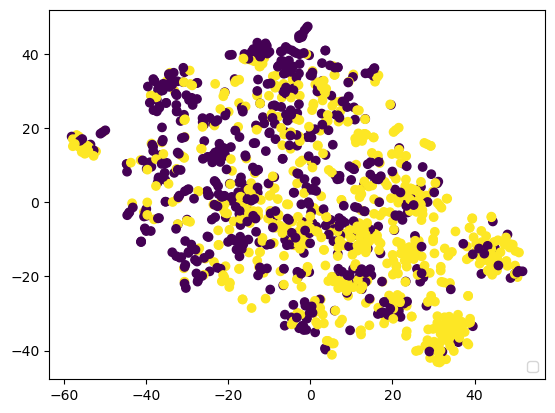

After Oversampling
Final_Ytrain
 0  
1.0    645
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9498787388843978
Training MCC Score: 0.8995929469295705
Training F1 Score: 0.9497565590180601
Training AUC VALUE: 0.9931122983448565
Training kappa Score: 0.8995173310134477
Training Precision: 0.9464012251148545
Training Recall: 0.958139534883721
Training Sensitivity: 0.958139534883721
Training Specificity: 0.9408783783783784
Training CCR: 0.9498787388843978
Training PPV: 0.9464012251148545


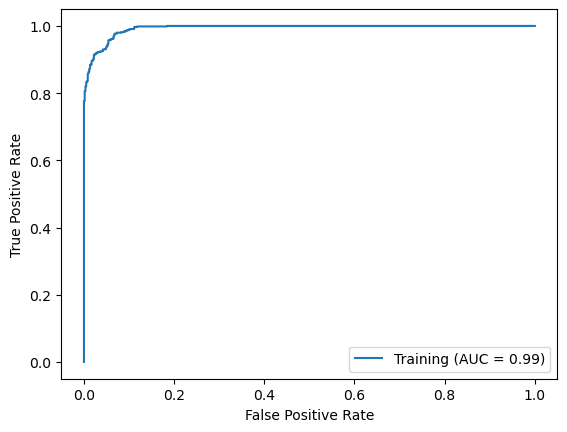

Testing Accuracy: 0.6655405405405406
Testing MCC Score: 0.31876160149461724
Testing F1 Score: 0.6576275542989334
Testing AUC VALUE: 0.713554561035993
Testing kappa Score: 0.317050433485597
Testing Precision: 0.7423312883435583
Testing Recall: 0.6797752808988764
Testing Sensitivity: 0.6797752808988764
Testing Specificity: 0.6440677966101694
Testing CCR: 0.6655405405405406
Testing PPV: 0.7423312883435583


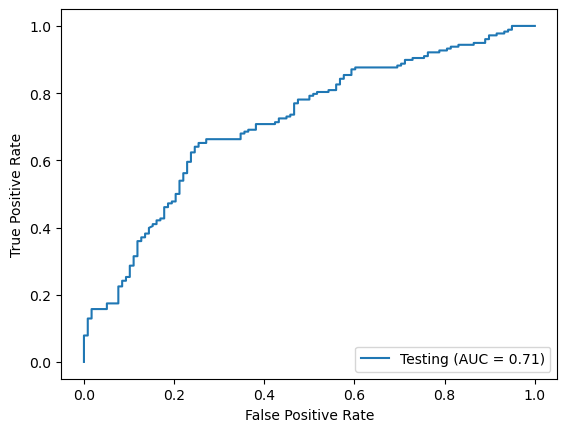

Fold # 1 Random Seed: 845
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-04 23:56:14,454:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:56:14,455:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:56:14,456:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 47
After filteration
Train shape
 (1184, 47) 
Test shape
 (296, 47)
Before Oversampling
y_train_filtered
 1.0    655
0.0    529
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


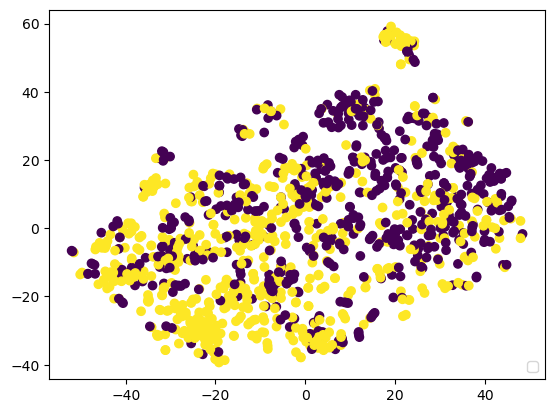

After Oversampling
Final_Ytrain
 0  
1.0    655
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9967923015236567
Training MCC Score: 0.9935743674697619
Training F1 Score: 0.996784607371423
Training AUC VALUE: 0.9999767897668661
Training kappa Score: 0.9935692313245991
Training Precision: 0.998468606431853
Training Recall: 0.9954198473282443
Training Sensitivity: 0.9954198473282443
Training Specificity: 0.9983108108108109
Training CCR: 0.9967923015236567
Training PPV: 0.998468606431853


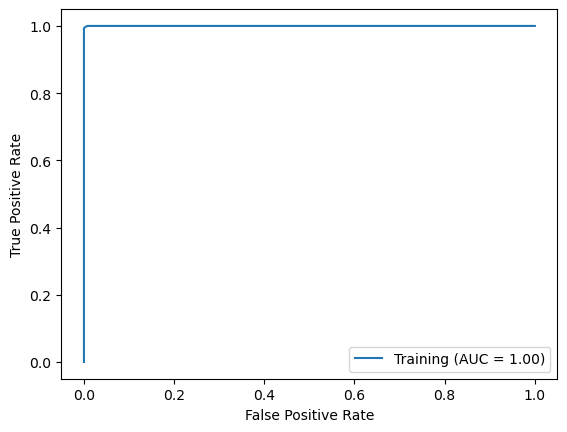

Testing Accuracy: 0.7331081081081081
Testing MCC Score: 0.45579186156784157
Testing F1 Score: 0.7278873567231047
Testing AUC VALUE: 0.7602074032738095
Testing kappa Score: 0.4557810463600819
Testing Precision: 0.7633136094674556
Testing Recall: 0.7678571428571429
Testing Sensitivity: 0.7678571428571429
Testing Specificity: 0.6875
Testing CCR: 0.7331081081081081
Testing PPV: 0.7633136094674556


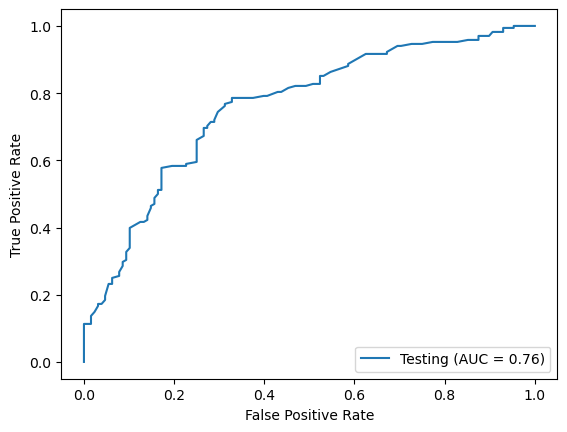

Fold # 2 Random Seed: 874
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-04 23:56:42,520:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:56:42,521:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:56:42,521:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 50
After filteration
Train shape
 (1184, 50) 
Test shape
 (296, 50)
Before Oversampling
y_train_filtered
 1.0    651
0.0    533
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


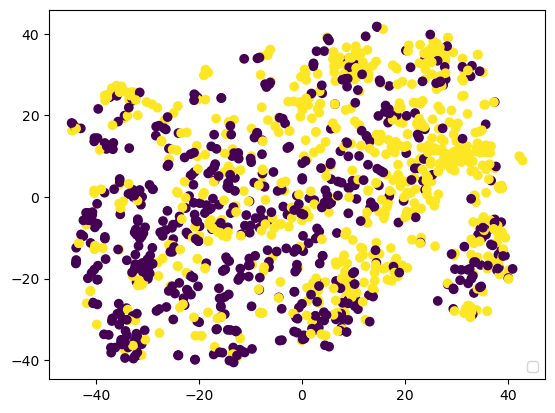

After Oversampling
Final_Ytrain
 0  
1.0    651
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9501206757843926
Training MCC Score: 0.9000930268011482
Training F1 Score: 0.9499574028186866
Training AUC VALUE: 0.9911038630796695
Training kappa Score: 0.8999241633293338
Training Precision: 0.9441930618401206
Training Recall: 0.9615975422427036
Training Sensitivity: 0.9615975422427036
Training Specificity: 0.9375
Training CCR: 0.9501206757843926
Training PPV: 0.9441930618401206


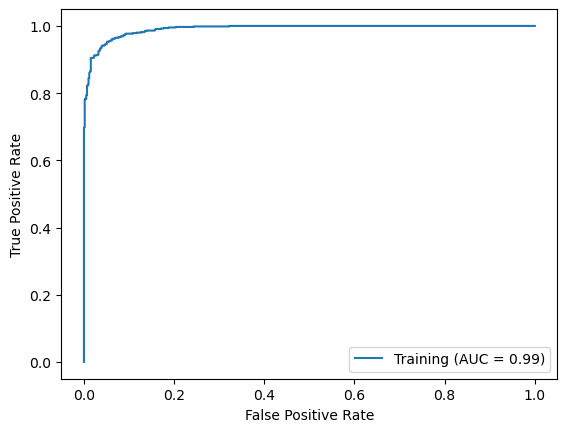

Testing Accuracy: 0.6621621621621622
Testing MCC Score: 0.3163916914145934
Testing F1 Score: 0.6570898980537535
Testing AUC VALUE: 0.7170855213803451
Testing kappa Score: 0.31532198371576614
Testing Precision: 0.725
Testing Recall: 0.6744186046511628
Testing Sensitivity: 0.6744186046511628
Testing Specificity: 0.6451612903225806
Testing CCR: 0.6621621621621622
Testing PPV: 0.725


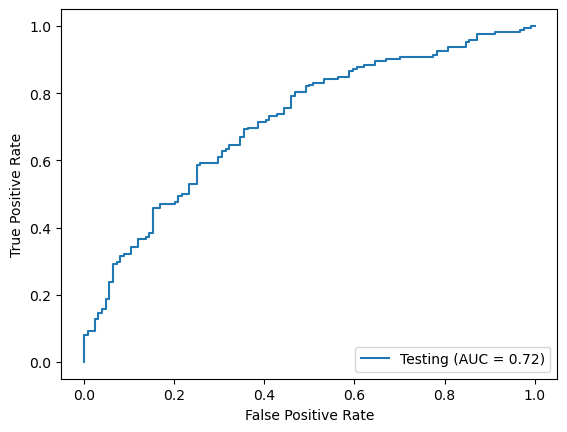

Fold # 3 Random Seed: 547
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-04 23:57:12,745:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:57:12,746:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:57:12,746:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 58
After filteration
Train shape
 (1184, 58) 
Test shape
 (296, 58)
Before Oversampling
y_train_filtered
 1.0    668
0.0    516
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


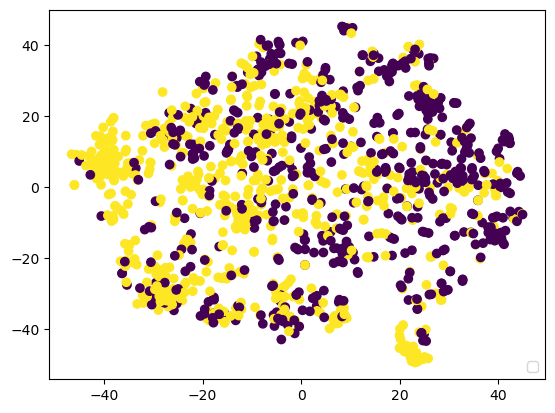

After Oversampling
Final_Ytrain
 0  
1.0    668
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9952380952380953
Training MCC Score: 0.990481201976313
Training F1 Score: 0.9952178412475109
Training AUC VALUE: 0.999959540378702
Training kappa Score: 0.9904359002904652
Training Precision: 0.9910979228486647
Training Recall: 1.0
Training Sensitivity: 1.0
Training Specificity: 0.9898648648648649
Training CCR: 0.9952380952380953
Training PPV: 0.9910979228486647


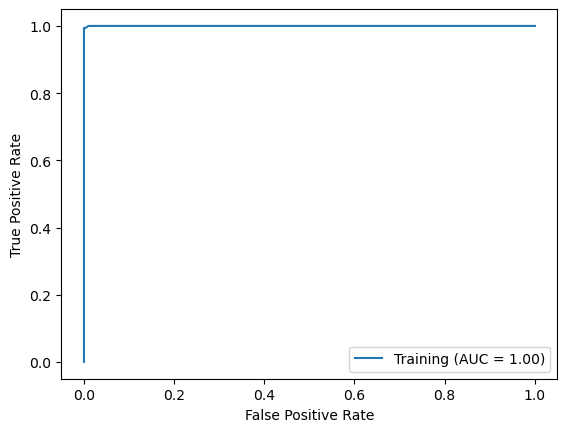

Testing Accuracy: 0.6385135135135135
Testing MCC Score: 0.27440165975487407
Testing F1 Score: 0.6370179359349035
Testing AUC VALUE: 0.6916952642415923
Testing kappa Score: 0.274243813015582
Testing Precision: 0.65
Testing Recall: 0.6709677419354839
Testing Sensitivity: 0.6709677419354839
Testing Specificity: 0.6028368794326241
Testing CCR: 0.6385135135135135
Testing PPV: 0.65


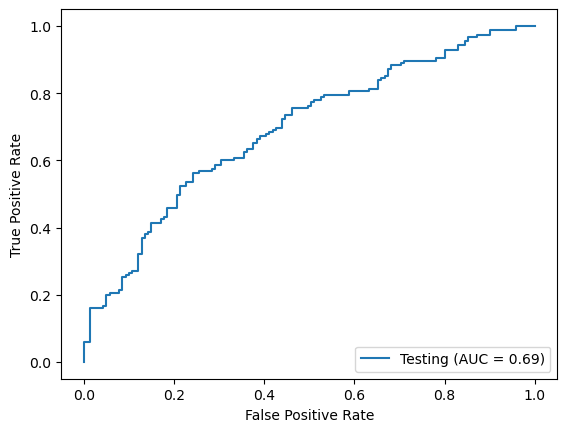

Fold # 4 Random Seed: 817
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-04 23:57:45,202:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:57:45,204:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:57:45,205:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 55
After filteration
Train shape
 (1184, 55) 
Test shape
 (296, 55)
Before Oversampling
y_train_filtered
 1.0    668
0.0    516
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


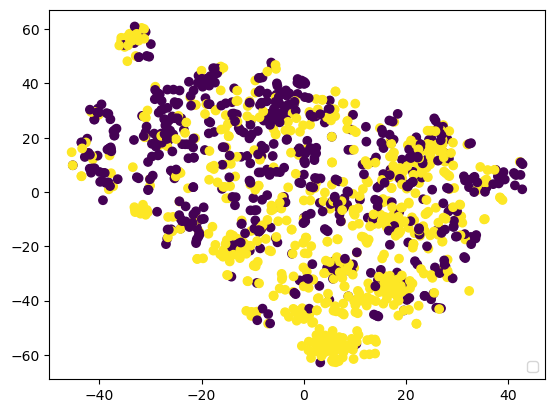

After Oversampling
Final_Ytrain
 0  
1.0    668
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9801587301587301
Training MCC Score: 0.9602781888314907
Training F1 Score: 0.980063682294841
Training AUC VALUE: 0.998284259184334
Training kappa Score: 0.9601304178332211
Training Precision: 0.9734904270986745
Training Recall: 0.9895209580838323
Training Sensitivity: 0.9895209580838323
Training Specificity: 0.9695945945945946
Training CCR: 0.9801587301587301
Training PPV: 0.9734904270986745


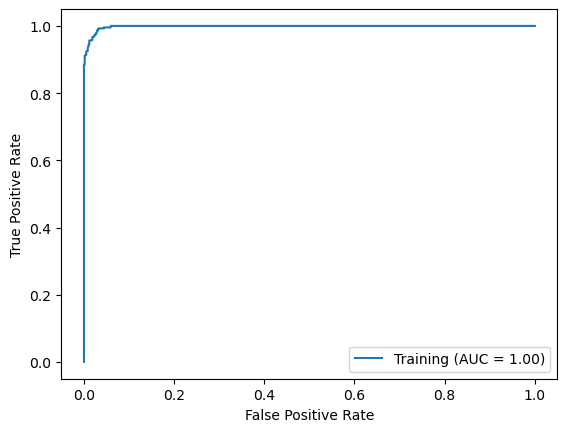

Testing Accuracy: 0.6925675675675675
Testing MCC Score: 0.38965646503500273
Testing F1 Score: 0.6925359845674433
Testing AUC VALUE: 0.7424845573095402
Testing kappa Score: 0.3870938381723855
Testing Precision: 0.7318840579710145
Testing Recall: 0.6516129032258065
Testing Sensitivity: 0.6516129032258065
Testing Specificity: 0.7375886524822695
Testing CCR: 0.6925675675675675
Testing PPV: 0.7318840579710145


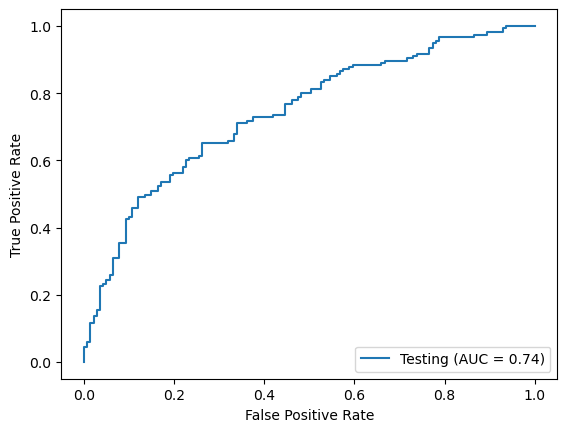

Fold # 5 Random Seed: 707
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-04 23:58:22,913:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:58:22,915:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:58:22,916:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 40
After filteration
Train shape
 (1184, 40) 
Test shape
 (296, 40)
Before Oversampling
y_train_filtered
 1.0    649
0.0    535
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


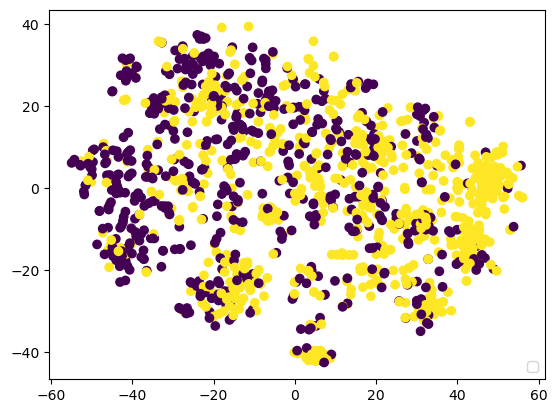

After Oversampling
Final_Ytrain
 0  
1.0    649
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9726027397260274
Training MCC Score: 0.94520100527064
Training F1 Score: 0.9725599604599136
Training AUC VALUE: 0.9964498396701786
Training kappa Score: 0.9451222049964103
Training Precision: 0.9797191887675507
Training Recall: 0.9676425269645609
Training Sensitivity: 0.9676425269645609
Training Specificity: 0.9780405405405406
Training CCR: 0.9726027397260274
Training PPV: 0.9797191887675507


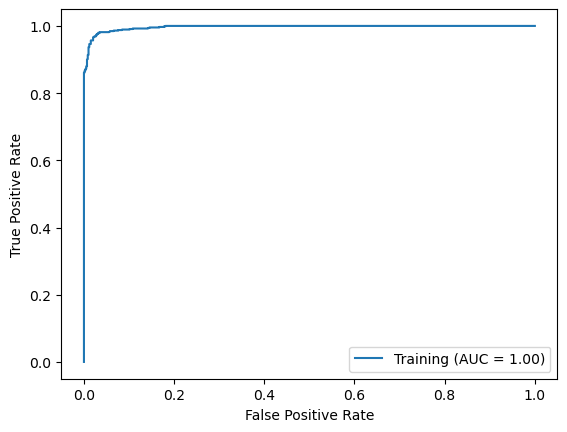

Testing Accuracy: 0.7398648648648649
Testing MCC Score: 0.4638298207556474
Testing F1 Score: 0.7319061342116098
Testing AUC VALUE: 0.7835406067458074
Testing kappa Score: 0.4638185753269972
Testing Precision: 0.7803468208092486
Testing Recall: 0.7758620689655172
Testing Sensitivity: 0.7758620689655172
Testing Specificity: 0.6885245901639344
Testing CCR: 0.7398648648648649
Testing PPV: 0.7803468208092486


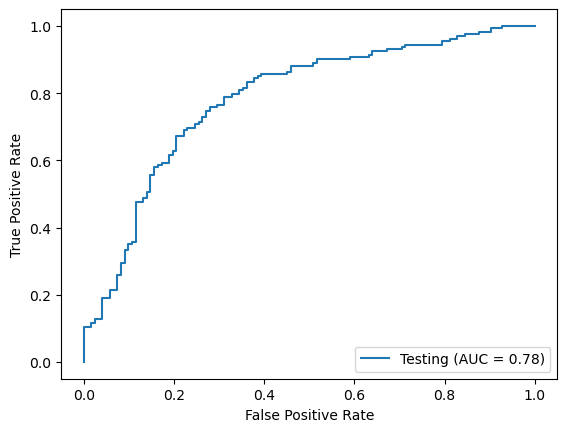

Fold # 6 Random Seed: 63
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-04 23:58:56,996:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:58:56,998:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:58:56,998:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 50
After filteration
Train shape
 (1184, 50) 
Test shape
 (296, 50)
Before Oversampling
y_train_filtered
 1.0    650
0.0    534
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


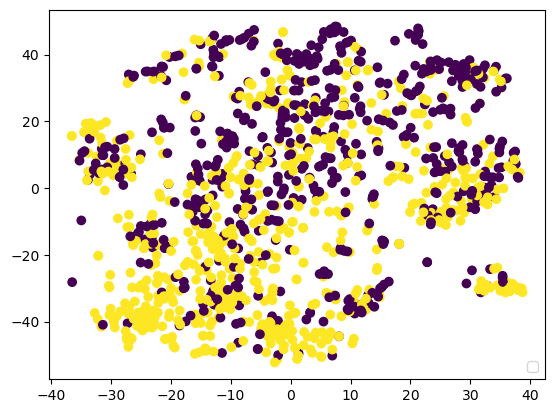

After Oversampling
Final_Ytrain
 0  
1.0    650
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9967793880837359
Training MCC Score: 0.9935446985446985
Training F1 Score: 0.9967723492723493
Training AUC VALUE: 0.9999766112266113
Training kappa Score: 0.9935446985446985
Training Precision: 0.9969230769230769
Training Recall: 0.9969230769230769
Training Sensitivity: 0.9969230769230769
Training Specificity: 0.9966216216216216
Training CCR: 0.9967793880837359
Training PPV: 0.9969230769230769


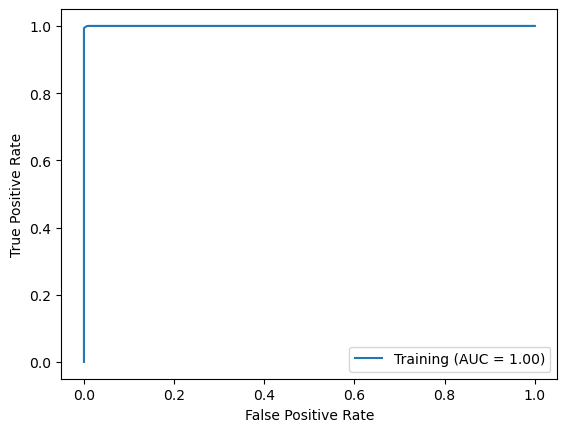

Testing Accuracy: 0.6554054054054054
Testing MCC Score: 0.2889253499032347
Testing F1 Score: 0.644431882419446
Testing AUC VALUE: 0.708726913858734
Testing kappa Score: 0.28889726317772857
Testing Precision: 0.7028571428571428
Testing Recall: 0.7109826589595376
Testing Sensitivity: 0.7109826589595376
Testing Specificity: 0.5772357723577236
Testing CCR: 0.6554054054054054
Testing PPV: 0.7028571428571428


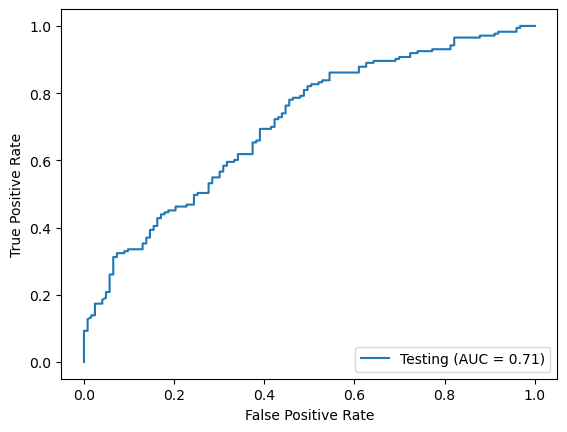

Fold # 7 Random Seed: 315
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-04 23:59:32,257:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 23:59:32,258:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 23:59:32,259:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 51
After filteration
Train shape
 (1184, 51) 
Test shape
 (296, 51)
Before Oversampling
y_train_filtered
 1.0    652
0.0    532
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


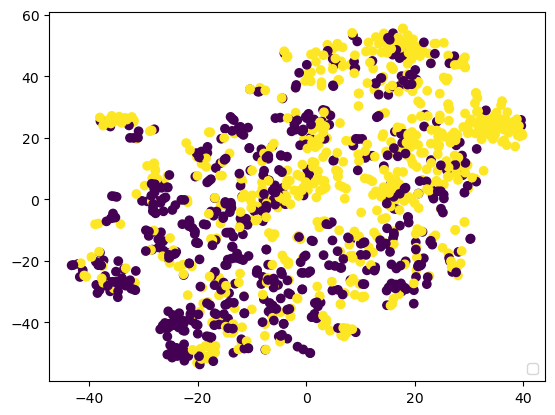

After Oversampling
Final_Ytrain
 0  
1.0    652
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9911575562700965
Training MCC Score: 0.9823649350688833
Training F1 Score: 0.9911302685096659
Training AUC VALUE: 0.9996049059028354
Training kappa Score: 0.9822614683418284
Training Precision: 0.9848714069591528
Training Recall: 0.9984662576687117
Training Sensitivity: 0.9984662576687117
Training Specificity: 0.9831081081081081
Training CCR: 0.9911575562700965
Training PPV: 0.9848714069591528


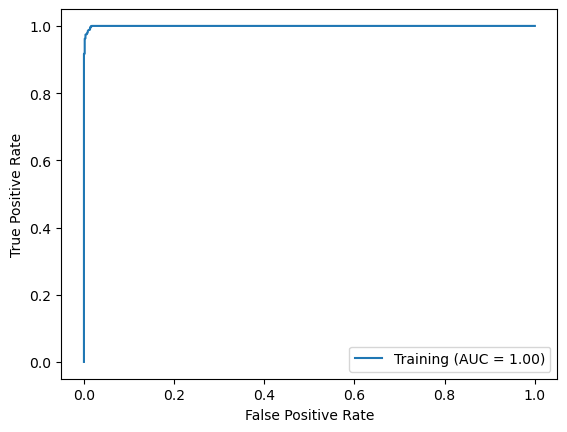

Testing Accuracy: 0.6891891891891891
Testing MCC Score: 0.3580223419510686
Testing F1 Score: 0.6784887839433293
Testing AUC VALUE: 0.7254736842105263
Testing kappa Score: 0.3574630739464867
Testing Precision: 0.7206703910614525
Testing Recall: 0.7543859649122807
Testing Sensitivity: 0.7543859649122807
Testing Specificity: 0.6
Testing CCR: 0.6891891891891891
Testing PPV: 0.7206703910614525


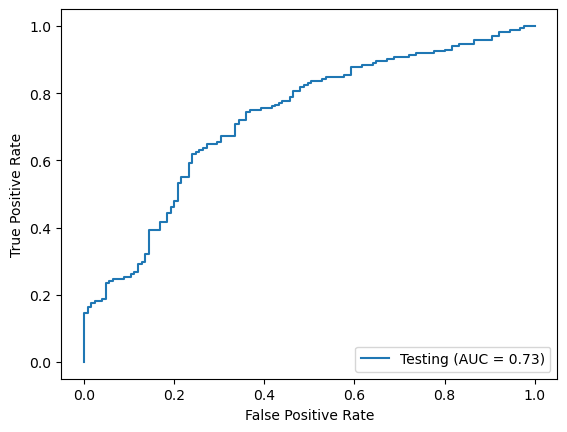

Fold # 8 Random Seed: 546
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-05 00:00:05,355:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:00:05,356:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:00:05,357:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 51
After filteration
Train shape
 (1184, 51) 
Test shape
 (296, 51)
Before Oversampling
y_train_filtered
 1.0    657
0.0    527
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


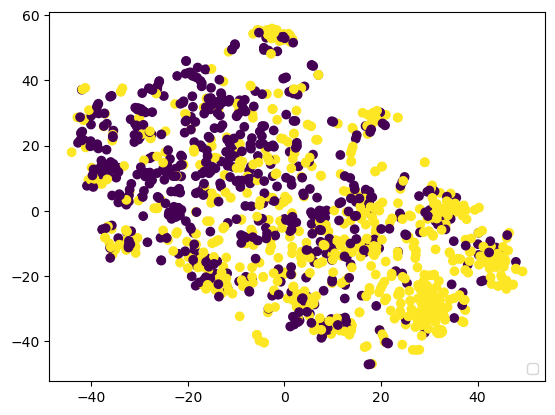

After Oversampling
Final_Ytrain
 0  
1.0    657
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9287429943955164
Training MCC Score: 0.8571014365153657
Training F1 Score: 0.9284781804436295
Training AUC VALUE: 0.9866240384219837
Training kappa Score: 0.8569674962974781
Training Precision: 0.9251497005988024
Training Recall: 0.9406392694063926
Training Sensitivity: 0.9406392694063926
Training Specificity: 0.9155405405405406
Training CCR: 0.9287429943955164
Training PPV: 0.9251497005988024


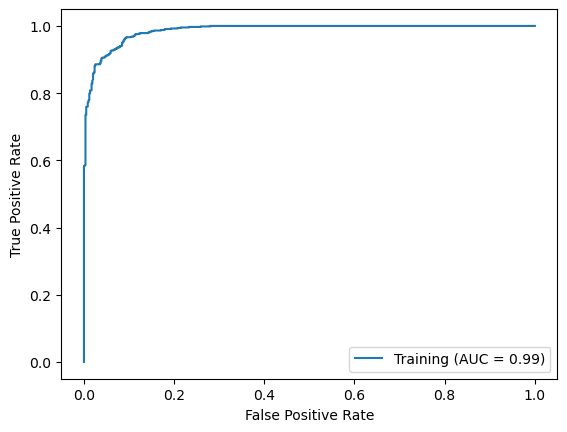

Testing Accuracy: 0.7195945945945946
Testing MCC Score: 0.4303041724904439
Testing F1 Score: 0.7151437151437151
Testing AUC VALUE: 0.7674698795180723
Testing kappa Score: 0.4302940358037288
Testing Precision: 0.7485029940119761
Testing Recall: 0.7530120481927711
Testing Sensitivity: 0.7530120481927711
Testing Specificity: 0.676923076923077
Testing CCR: 0.7195945945945946
Testing PPV: 0.7485029940119761


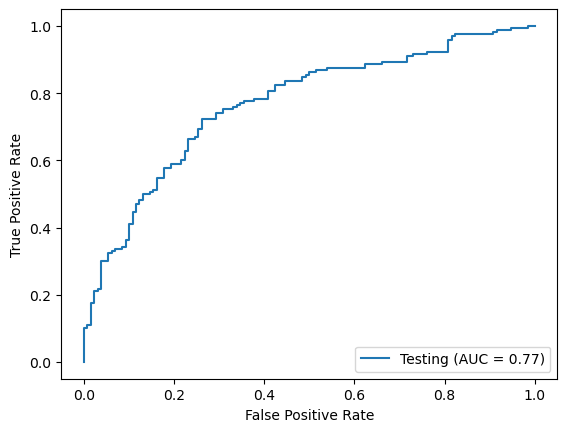

Fold # 9 Random Seed: 974
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-05 00:00:36,357:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:00:36,359:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:00:36,360:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 55
After filteration
Train shape
 (1184, 55) 
Test shape
 (296, 55)
Before Oversampling
y_train_filtered
 1.0    653
0.0    531
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


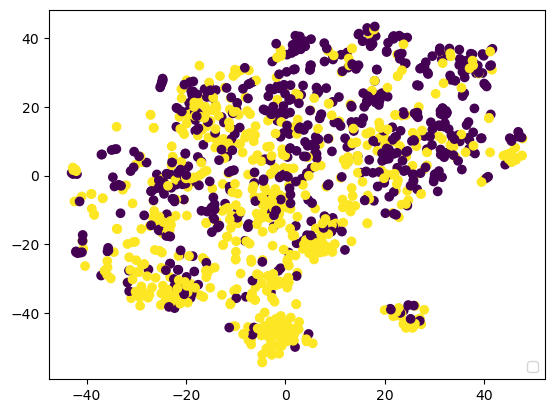

After Oversampling
Final_Ytrain
 0  
1.0    653
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9783132530120482
Training MCC Score: 0.9566347149780956
Training F1 Score: 0.9782404791172683
Training AUC VALUE: 0.9988255866892926
Training kappa Score: 0.9564843666057806
Training Precision: 0.9713855421686747
Training Recall: 0.9877488514548239
Training Sensitivity: 0.9877488514548239
Training Specificity: 0.9679054054054054
Training CCR: 0.9783132530120482
Training PPV: 0.9713855421686747


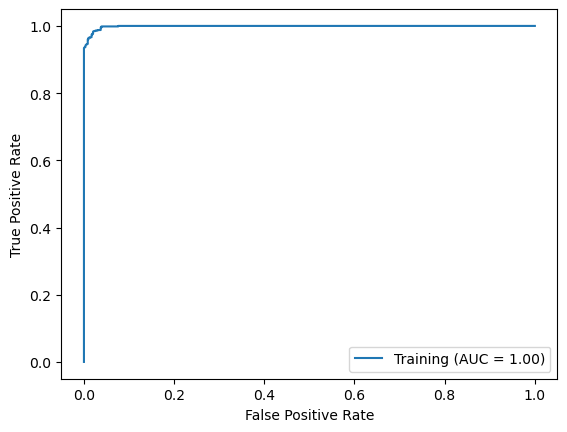

Testing Accuracy: 0.6756756756756757
Testing MCC Score: 0.34593258549515216
Testing F1 Score: 0.6718403547671841
Testing AUC VALUE: 0.7546685340802988
Testing kappa Score: 0.344770337576093
Testing Precision: 0.7341772151898734
Testing Recall: 0.6823529411764706
Testing Sensitivity: 0.6823529411764706
Testing Specificity: 0.6666666666666666
Testing CCR: 0.6756756756756757
Testing PPV: 0.7341772151898734


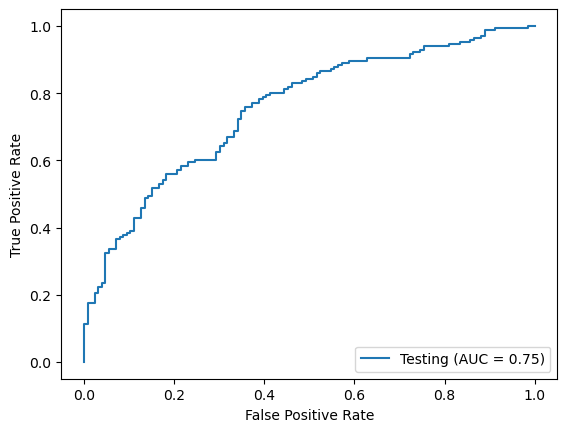

Fold # 10 Random Seed: 135
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-05 00:01:07,122:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:01:07,123:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:01:07,124:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 52
After filteration
Train shape
 (1184, 52) 
Test shape
 (296, 52)
Before Oversampling
y_train_filtered
 1.0    660
0.0    524
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


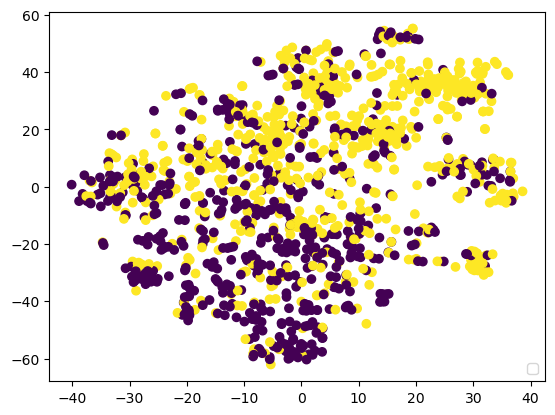

After Oversampling
Final_Ytrain
 0  
1.0    660
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.994408945686901
Training MCC Score: 0.9887870522462517
Training F1 Score: 0.9943928881040809
Training AUC VALUE: 0.9996979934479935
Training kappa Score: 0.9887857833828956
Training Precision: 0.9954476479514416
Training Recall: 0.9939393939393939
Training Sensitivity: 0.9939393939393939
Training Specificity: 0.9949324324324325
Training CCR: 0.994408945686901
Training PPV: 0.9954476479514416


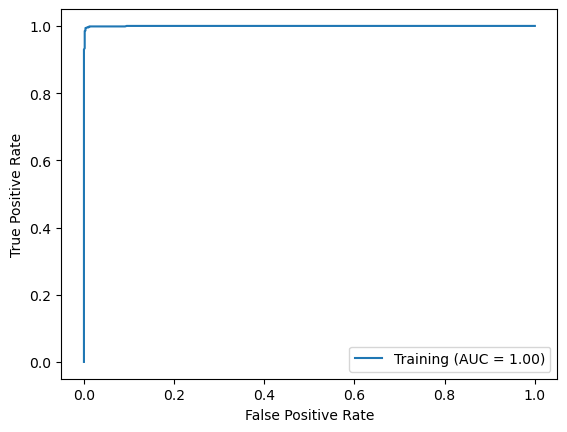

Testing Accuracy: 0.6722972972972973
Testing MCC Score: 0.3425296917546285
Testing F1 Score: 0.6706395182104962
Testing AUC VALUE: 0.7242723372849301
Testing kappa Score: 0.34189052901806183
Testing Precision: 0.7142857142857143
Testing Recall: 0.6748466257668712
Testing Sensitivity: 0.6748466257668712
Testing Specificity: 0.6691729323308271
Testing CCR: 0.6722972972972973
Testing PPV: 0.7142857142857143


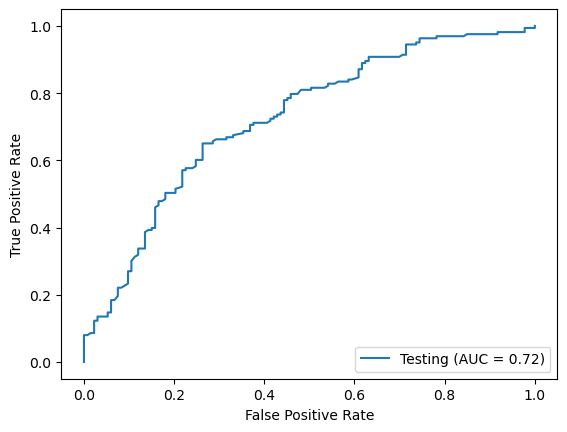

Fold # 11 Random Seed: 715
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-05 00:01:35,480:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:01:35,482:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:01:35,482:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 44
After filteration
Train shape
 (1184, 44) 
Test shape
 (296, 44)
Before Oversampling
y_train_filtered
 1.0    665
0.0    519
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


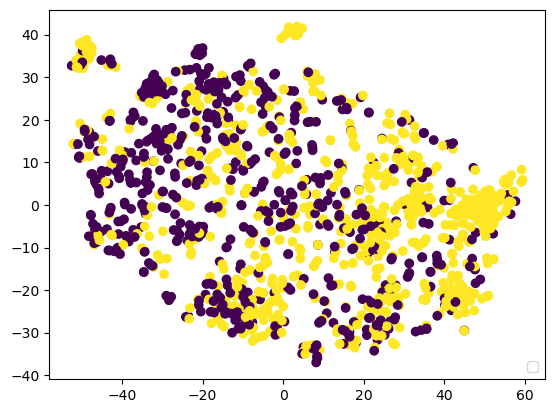

After Oversampling
Final_Ytrain
 0  
1.0    665
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9896579156722355
Training MCC Score: 0.9793759843376861
Training F1 Score: 0.9896115240182252
Training AUC VALUE: 0.9996151696809591
Training kappa Score: 0.9792246461477045
Training Precision: 0.9822485207100592
Training Recall: 0.9984962406015038
Training Sensitivity: 0.9984962406015038
Training Specificity: 0.9797297297297297
Training CCR: 0.9896579156722355
Training PPV: 0.9822485207100592


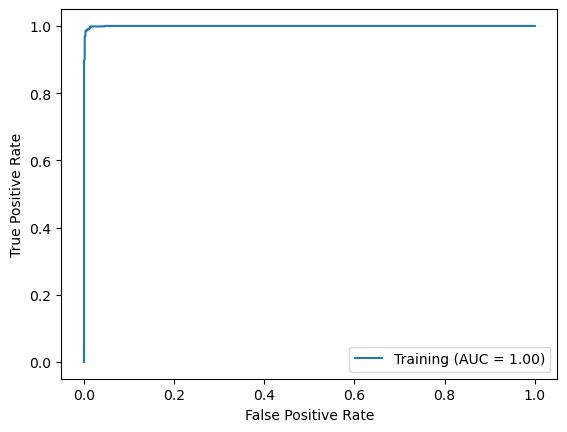

Testing Accuracy: 0.7094594594594594
Testing MCC Score: 0.41820090104639823
Testing F1 Score: 0.708808053077099
Testing AUC VALUE: 0.7519262520638414
Testing kappa Score: 0.4178558360775705
Testing Precision: 0.7368421052631579
Testing Recall: 0.7088607594936709
Testing Sensitivity: 0.7088607594936709
Testing Specificity: 0.7101449275362319
Testing CCR: 0.7094594594594594
Testing PPV: 0.7368421052631579


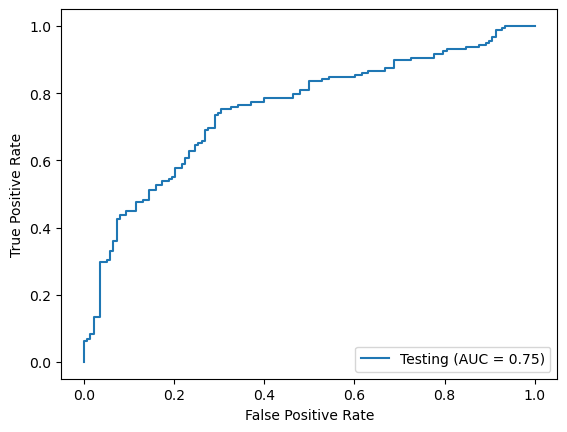

Fold # 12 Random Seed: 24
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-05 00:02:02,556:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:02:02,558:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:02:02,558:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 52
After filteration
Train shape
 (1184, 52) 
Test shape
 (296, 52)
Before Oversampling
y_train_filtered
 1.0    649
0.0    535
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


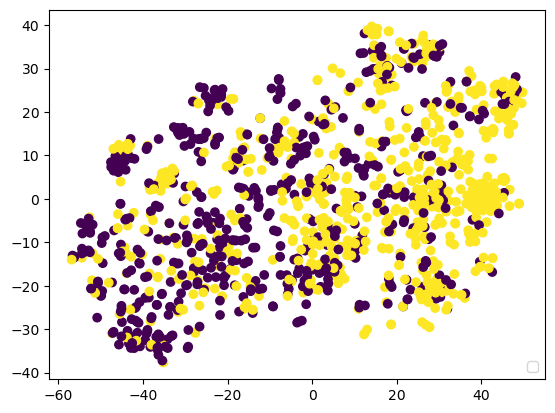

After Oversampling
Final_Ytrain
 0  
1.0    649
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8799355358581789
Training MCC Score: 0.7592989086129537
Training F1 Score: 0.8796351083849693
Training AUC VALUE: 0.9541836713446883
Training kappa Score: 0.7592741342297082
Training Precision: 0.882262996941896
Training Recall: 0.889060092449923
Training Sensitivity: 0.889060092449923
Training Specificity: 0.8699324324324325
Training CCR: 0.8799355358581789
Training PPV: 0.882262996941896


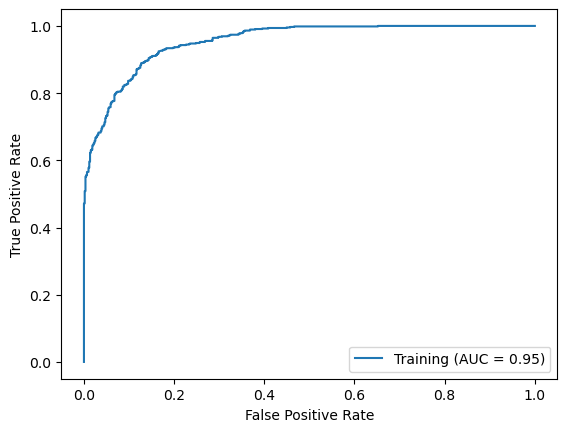

Testing Accuracy: 0.6554054054054054
Testing MCC Score: 0.29062962089420785
Testing F1 Score: 0.6452840828986324
Testing AUC VALUE: 0.7178490672696438
Testing kappa Score: 0.2906015037593984
Testing Precision: 0.7093023255813954
Testing Recall: 0.7011494252873564
Testing Sensitivity: 0.7011494252873564
Testing Specificity: 0.5901639344262295
Testing CCR: 0.6554054054054054
Testing PPV: 0.7093023255813954


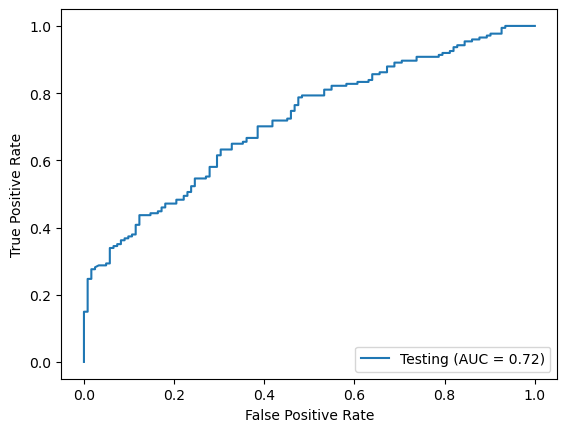

Fold # 13 Random Seed: 505
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-05 00:02:30,846:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:02:30,848:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:02:30,848:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 44
After filteration
Train shape
 (1184, 44) 
Test shape
 (296, 44)
Before Oversampling
y_train_filtered
 1.0    667
0.0    517
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


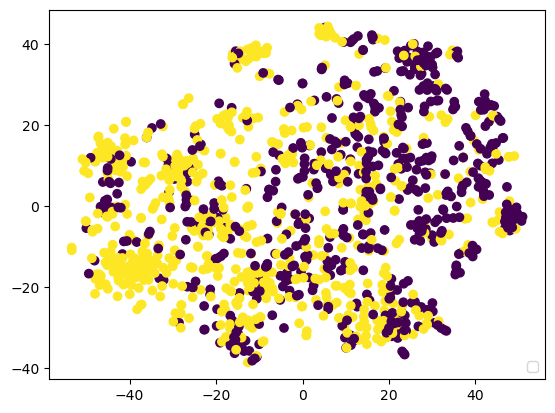

After Oversampling
Final_Ytrain
 0  
1.0    667
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9984114376489277
Training MCC Score: 0.9968172309132158
Training F1 Score: 0.9984060789288445
Training AUC VALUE: 0.9999886036711374
Training kappa Score: 0.996812165929422
Training Precision: 1.0
Training Recall: 0.9970014992503748
Training Sensitivity: 0.9970014992503748
Training Specificity: 1.0
Training CCR: 0.9984114376489277
Training PPV: 1.0


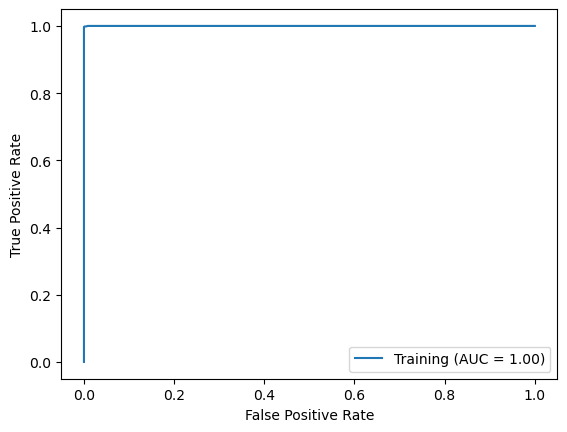

Testing Accuracy: 0.6790540540540541
Testing MCC Score: 0.3546172583523581
Testing F1 Score: 0.6763612508200307
Testing AUC VALUE: 0.7404075091575092
Testing kappa Score: 0.3536226553880103
Testing Precision: 0.6826347305389222
Testing Recall: 0.7307692307692307
Testing Sensitivity: 0.7307692307692307
Testing Specificity: 0.6214285714285714
Testing CCR: 0.6790540540540541
Testing PPV: 0.6826347305389222


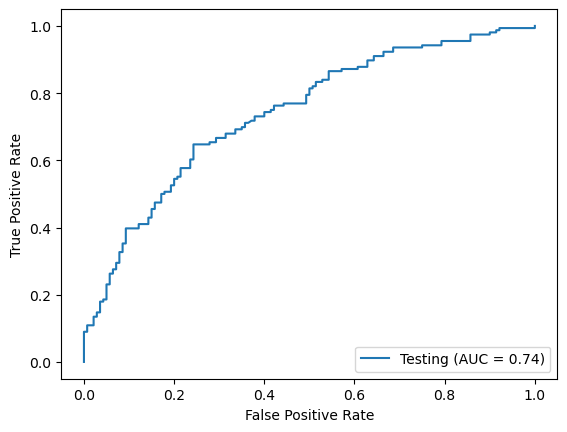

Fold # 14 Random Seed: 23
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-05 00:02:57,712:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:02:57,713:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:02:57,714:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 58
After filteration
Train shape
 (1184, 58) 
Test shape
 (296, 58)
Before Oversampling
y_train_filtered
 1.0    663
0.0    521
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


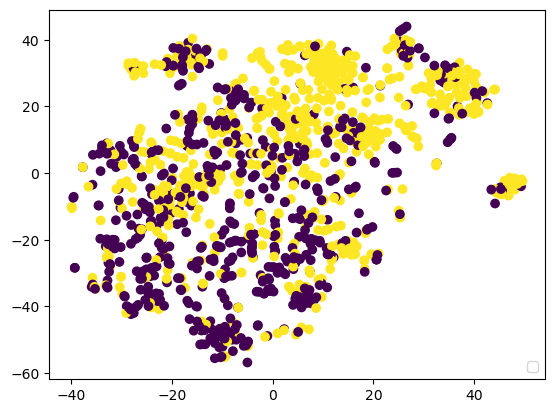

After Oversampling
Final_Ytrain
 0  
1.0    663
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.999203187250996
Training MCC Score: 0.998402677897781
Training F1 Score: 0.999200700581164
Training AUC VALUE: 0.9999987261016673
Training kappa Score: 0.9984014021804619
Training Precision: 1.0
Training Recall: 0.9984917043740573
Training Sensitivity: 0.9984917043740573
Training Specificity: 1.0
Training CCR: 0.999203187250996
Training PPV: 1.0


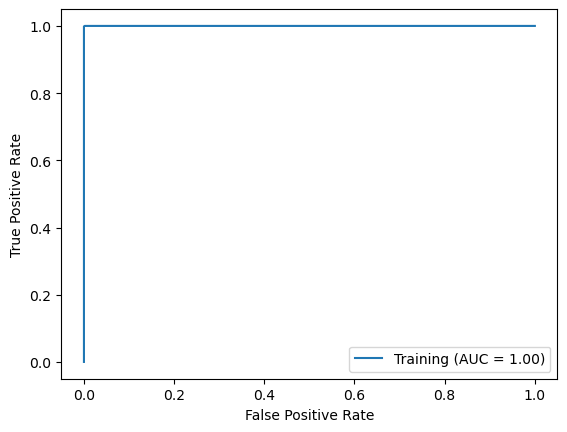

Testing Accuracy: 0.6858108108108109
Testing MCC Score: 0.3659271167142984
Testing F1 Score: 0.6827657735522904
Testing AUC VALUE: 0.7226792279411764
Testing kappa Score: 0.36571428571428566
Testing Precision: 0.703030303030303
Testing Recall: 0.725
Testing Sensitivity: 0.725
Testing Specificity: 0.6397058823529411
Testing CCR: 0.6858108108108109
Testing PPV: 0.703030303030303


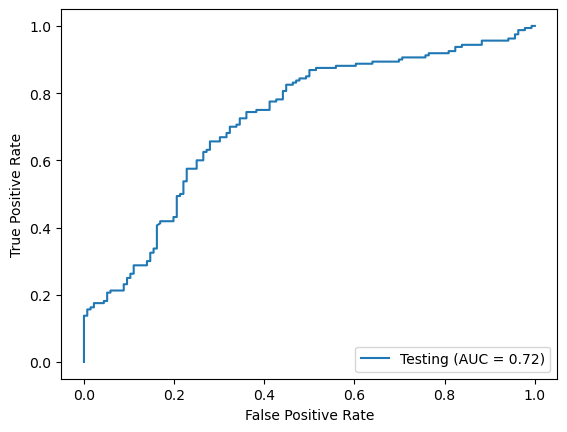

Fold # 15 Random Seed: 260
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-05 00:03:28,135:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:03:28,137:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:03:28,138:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 47
After filteration
Train shape
 (1184, 47) 
Test shape
 (296, 47)
Before Oversampling
y_train_filtered
 1.0    657
0.0    527
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


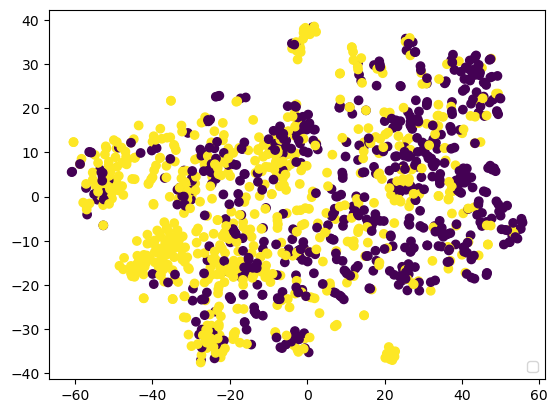

After Oversampling
Final_Ytrain
 0  
1.0    657
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9967974379503602
Training MCC Score: 0.9935774815911802
Training F1 Score: 0.9967887407955901
Training AUC VALUE: 0.9999665761652063
Training kappa Score: 0.9935774815911802
Training Precision: 0.9969558599695586
Training Recall: 0.9969558599695586
Training Sensitivity: 0.9969558599695586
Training Specificity: 0.9966216216216216
Training CCR: 0.9967974379503602
Training PPV: 0.9969558599695586


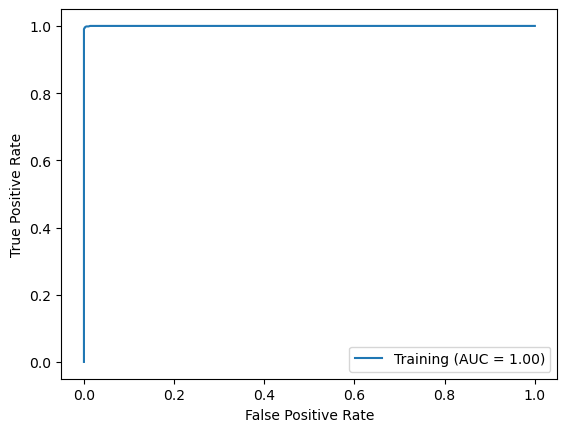

Testing Accuracy: 0.6891891891891891
Testing MCC Score: 0.36392583494439074
Testing F1 Score: 0.6807951987997
Testing AUC VALUE: 0.7400602409638554
Testing kappa Score: 0.36266616738438495
Testing Precision: 0.7078651685393258
Testing Recall: 0.7590361445783133
Testing Sensitivity: 0.7590361445783133
Testing Specificity: 0.6
Testing CCR: 0.6891891891891891
Testing PPV: 0.7078651685393258


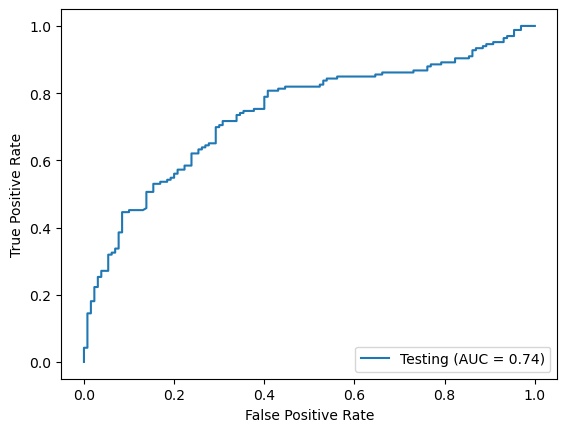

Fold # 16 Random Seed: 853
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-05 00:04:05,738:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:04:05,740:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:04:05,741:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 59
After filteration
Train shape
 (1184, 59) 
Test shape
 (296, 59)
Before Oversampling
y_train_filtered
 1.0    662
0.0    522
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


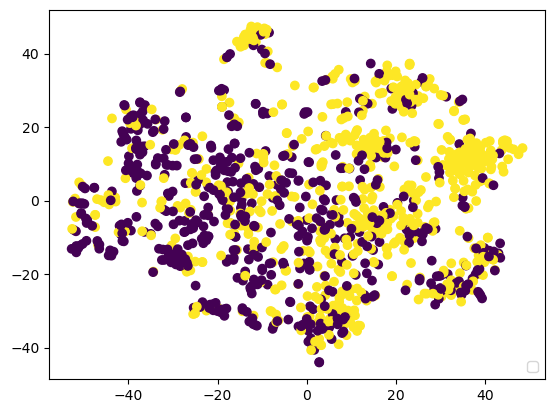

After Oversampling
Final_Ytrain
 0  
1.0    662
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9984051036682615
Training MCC Score: 0.9968002367926839
Training F1 Score: 0.998400118396342
Training AUC VALUE: 0.9998685902670041
Training kappa Score: 0.9968002367926839
Training Precision: 0.9984894259818731
Training Recall: 0.9984894259818731
Training Sensitivity: 0.9984894259818731
Training Specificity: 0.9983108108108109
Training CCR: 0.9984051036682615
Training PPV: 0.9984894259818731


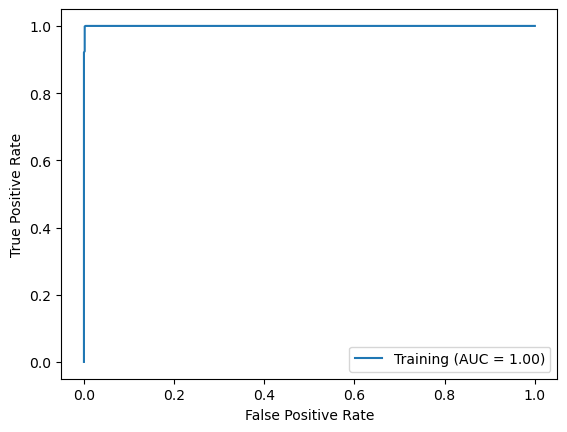

Testing Accuracy: 0.6756756756756757
Testing MCC Score: 0.3463077984817115
Testing F1 Score: 0.6731538992408558
Testing AUC VALUE: 0.7291465378421901
Testing kappa Score: 0.34630779848171145
Testing Precision: 0.7018633540372671
Testing Recall: 0.7018633540372671
Testing Sensitivity: 0.7018633540372671
Testing Specificity: 0.6444444444444445
Testing CCR: 0.6756756756756757
Testing PPV: 0.7018633540372671


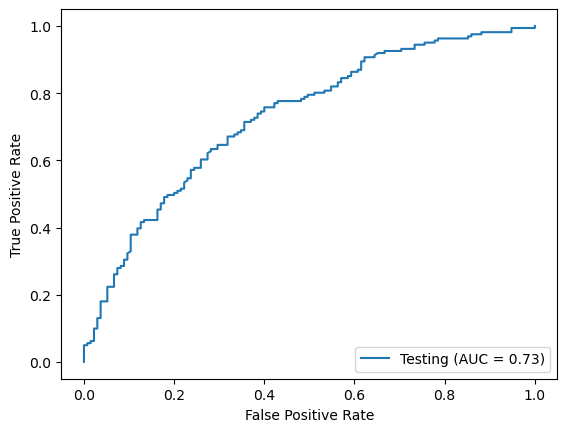

Fold # 17 Random Seed: 739
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-05 00:04:46,503:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:04:46,505:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:04:46,506:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 49
After filteration
Train shape
 (1184, 49) 
Test shape
 (296, 49)
Before Oversampling
y_train_filtered
 1.0    655
0.0    529
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


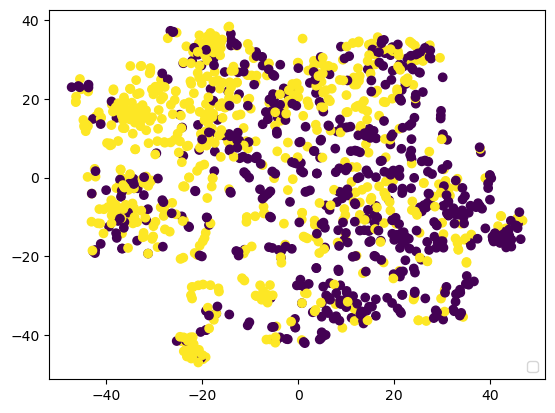

After Oversampling
Final_Ytrain
 0  
1.0    655
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9967923015236567
Training MCC Score: 0.9935681865071178
Training F1 Score: 0.9967840932535589
Training AUC VALUE: 0.9999793686816587
Training kappa Score: 0.9935681865071178
Training Precision: 0.9969465648854962
Training Recall: 0.9969465648854962
Training Sensitivity: 0.9969465648854962
Training Specificity: 0.9966216216216216
Training CCR: 0.9967923015236567
Training PPV: 0.9969465648854962


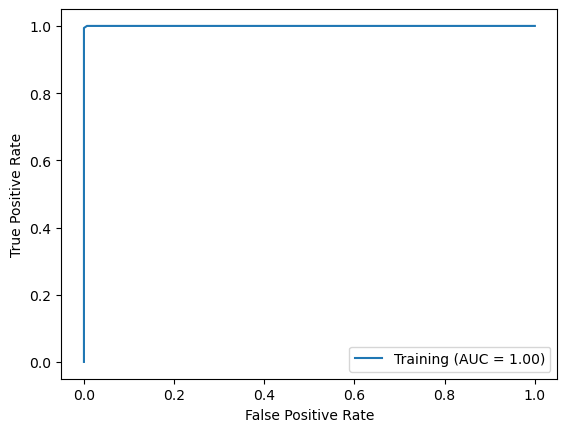

Testing Accuracy: 0.6655405405405406
Testing MCC Score: 0.3180116419762555
Testing F1 Score: 0.6589980799441439
Testing AUC VALUE: 0.7099376860119049
Testing kappa Score: 0.31800409607149505
Testing Precision: 0.7041420118343196
Testing Recall: 0.7083333333333334
Testing Sensitivity: 0.7083333333333334
Testing Specificity: 0.609375
Testing CCR: 0.6655405405405406
Testing PPV: 0.7041420118343196


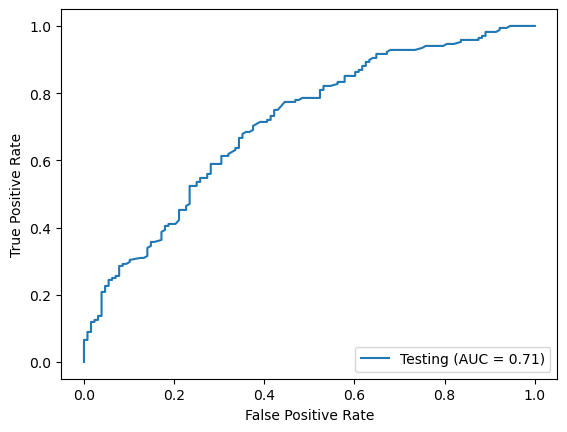

Fold # 18 Random Seed: 898
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-05 00:05:22,977:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:05:22,979:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:05:22,980:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 50
After filteration
Train shape
 (1184, 50) 
Test shape
 (296, 50)
Before Oversampling
y_train_filtered
 1.0    663
0.0    521
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


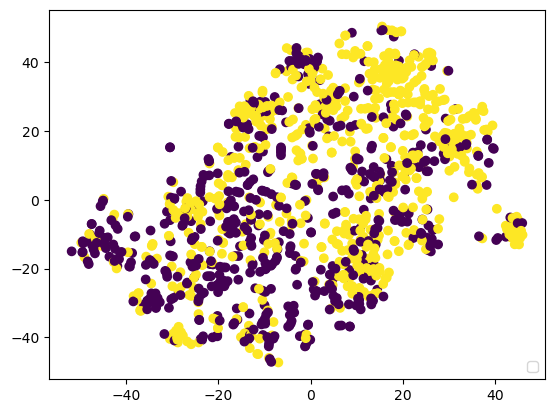

After Oversampling
Final_Ytrain
 0  
1.0    663
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9697211155378486
Training MCC Score: 0.9393550404577308
Training F1 Score: 0.9695880969507746
Training AUC VALUE: 0.9973413741796094
Training kappa Score: 0.9391817787639962
Training Precision: 0.9629629629629629
Training Recall: 0.9803921568627451
Training Sensitivity: 0.9803921568627451
Training Specificity: 0.9577702702702703
Training CCR: 0.9697211155378486
Training PPV: 0.9629629629629629


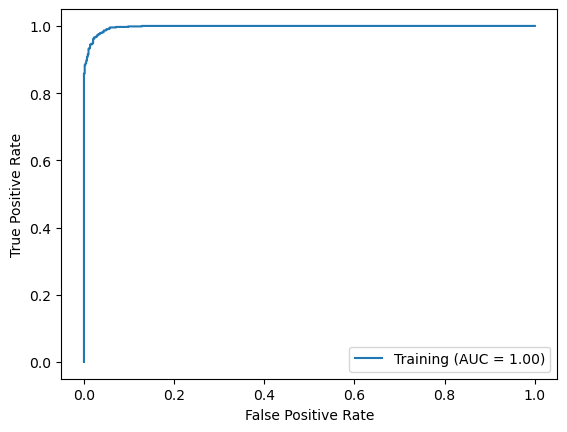

Testing Accuracy: 0.6858108108108109
Testing MCC Score: 0.3671227184200311
Testing F1 Score: 0.6835534710487291
Testing AUC VALUE: 0.733295036764706
Testing kappa Score: 0.36711421739930106
Testing Precision: 0.7080745341614907
Testing Recall: 0.7125
Testing Sensitivity: 0.7125
Testing Specificity: 0.6544117647058824
Testing CCR: 0.6858108108108109
Testing PPV: 0.7080745341614907


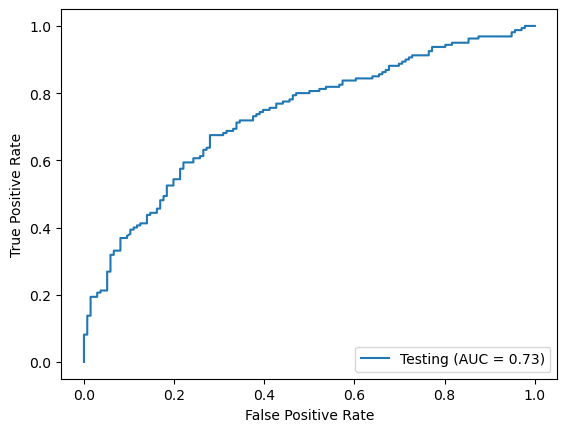

Fold # 19 Random Seed: 107
Before filteration
Train shape
 (1184, 3200) 
Test shape
 (296, 3200)


2024-11-05 00:05:59,670:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:05:59,671:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:05:59,672:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 49
After filteration
Train shape
 (1184, 49) 
Test shape
 (296, 49)
Before Oversampling
y_train_filtered
 1.0    673
0.0    511
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


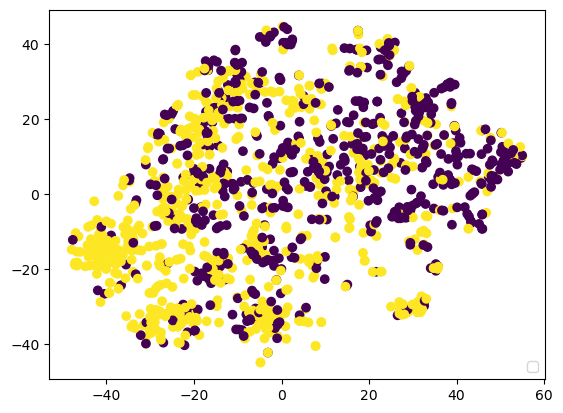

After Oversampling
Final_Ytrain
 0  
1.0    673
0.0    592
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9976284584980237
Training MCC Score: 0.9952381602755557
Training F1 Score: 0.9976184514474732
Training AUC VALUE: 0.9999849403638408
Training kappa Score: 0.9952369058840215
Training Precision: 0.9970326409495549
Training Recall: 0.9985141158989599
Training Sensitivity: 0.9985141158989599
Training Specificity: 0.9966216216216216
Training CCR: 0.9976284584980237
Training PPV: 0.9970326409495549


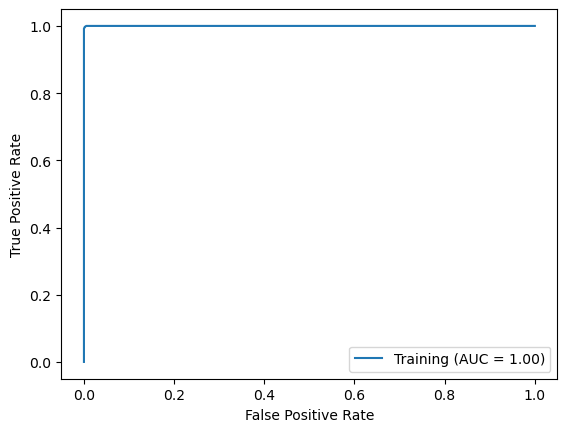

Testing Accuracy: 0.6891891891891891
Testing MCC Score: 0.38063278486006136
Testing F1 Score: 0.6871323529411765
Testing AUC VALUE: 0.7802739726027397
Testing kappa Score: 0.3771271729185728
Testing Precision: 0.6705882352941176
Testing Recall: 0.76
Testing Sensitivity: 0.76
Testing Specificity: 0.6164383561643836
Testing CCR: 0.6891891891891891
Testing PPV: 0.6705882352941176


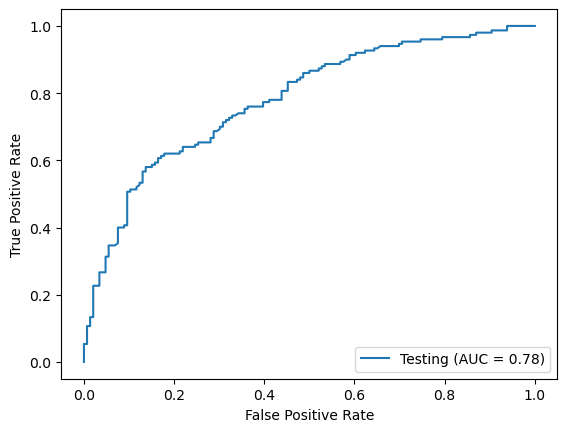

In [35]:
Train_Fold_outs=[]
Test_Fold_outs=[]
Best_params=[]
features = []
models=[]

#this chunk runs 20 iterations of the 5-Cross Validation of the pre-defined grid for the model
for i in range(20):
    #print('Fold #',i)   
    seed = random.randint(0, 1000)
    print('Fold #', i, "Random Seed:", seed)
    
    # Split Data
    X_train, X_test,y_train,y_test = train_test_split(Train,Train["status"] ,test_size=0.20, shuffle = True, random_state=seed)
    
    #Drop smiles,status from training,testing data
    x_train = X_train.drop(['status','smiles'], axis=1)
    x_test = X_test.drop(['status','smiles'], axis=1)

    #Feature selection
    x_train_filtered,x_test_filtered,y_train_filtered,y_test_filtered,selected_features = Boruta_Filteration(x_train,y_train,x_test,y_test)
    features.append(selected_features)
    
    y_train_filtered = pd.Series(y_train_filtered)

    print('Before Oversampling\ny_train_filtered\n',y_train_filtered.value_counts())
    #Oversampling
    Final_Xtrain,Final_Ytrain = Smote(x_train_filtered,y_train_filtered,0.5)
    print('After Oversampling\nFinal_Ytrain\n',Final_Ytrain.value_counts())
    
    Final_Ytrain=Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype = np.float64)
    x_test_filtered = pd.DataFrame(x_test_filtered, dtype = np.float64)
    
    #Hyperparameter Tuning
    Parameters = HPTing_Model(Final_Xtrain,Final_Ytrain)
    
    #save best parameters
    Best_params.append(Parameters.best_estimator_.get_params())
    
    #build the tuned model
    #edit the parameters here according to your defined parameter space and model's grid
    rf = RandomForestClassifier(max_features=Parameters.best_estimator_.get_params()['max_features'],
                        max_depth=Parameters.best_estimator_.get_params()['max_depth'],
                        min_samples_split=Parameters.best_estimator_.get_params()['min_samples_split'],
                        min_samples_leaf=Parameters.best_estimator_.get_params()['min_samples_leaf'],
                        bootstrap=Parameters.best_estimator_.get_params()['bootstrap'],
                        n_estimators=Parameters.best_estimator_.get_params()['n_estimators'])

    
    #fit the built model
    rf.fit(Final_Xtrain,Final_Ytrain)
    models.append(rf)

    #Training Predictions for the model
    y_train_pred=rf.predict(Final_Xtrain)
    y_train_prob=rf.predict_proba(Final_Xtrain)

    #Save training metrics
    Train_Fold_outs.append(Scoring_metrices(y_train_pred,y_train_prob[:,1],Final_Ytrain,'Training'))

    #Testing Predictions for the model
    y_test_pred=rf.predict(x_test_filtered) 
    y_test_prob=rf.predict_proba(x_test_filtered)

    #Save testing metrics
    Test_Fold_outs.append(Scoring_metrices(y_test_pred,y_test_prob[:,1],y_test_filtered,'Testing'))

In [39]:
#Analyse the testing metrics sorted by descending Testing Accuracy
pd.DataFrame.from_dict(Test_Fold_outs).sort_values(by=['Testing kappa Score:'],ascending = False)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
5,0.739865,0.463830,0.731906,0.783541,0.463819,0.780347,0.775862,0.775862,0.688525,0.739865,0.780347
1,0.733108,0.455792,0.727887,0.760207,0.455781,0.763314,0.767857,0.767857,0.687500,0.733108,0.763314
8,0.719595,0.430304,0.715144,0.767470,0.430294,0.748503,0.753012,0.753012,0.676923,0.719595,0.748503
11,0.709459,0.418201,0.708808,0.751926,0.417856,0.736842,0.708861,0.708861,0.710145,0.709459,0.736842
4,0.692568,0.389656,0.692536,0.742485,0.387094,0.731884,0.651613,0.651613,0.737589,0.692568,0.731884
19,0.689189,0.380633,0.687132,0.780274,0.377127,0.670588,0.760000,0.760000,0.616438,0.689189,0.670588
18,0.685811,0.367123,0.683553,0.733295,0.367114,0.708075,0.712500,0.712500,0.654412,0.685811,0.708075
14,0.685811,0.365927,0.682766,0.722679,0.365714,0.703030,0.725000,0.725000,0.639706,0.685811,0.703030
15,0.689189,0.363926,0.680795,0.740060,0.362666,0.707865,0.759036,0.759036,0.600000,0.689189,0.707865
7,0.689189,0.358022,0.678489,0.725474,0.357463,0.720670,0.754386,0.754386,0.600000,0.689189,0.720670


In [40]:
#View the best parameters
pd.DataFrame.from_dict(Best_params)

,bootstrap,ccp_alpha,class_weight,criterion,max_depth,max_features,max_leaf_nodes,max_samples,min_impurity_decrease,min_samples_leaf,min_samples_split,min_weight_fraction_leaf,n_estimators,n_jobs,oob_score,random_state,verbose,warm_start
0,True,0.0,None,gini,60.0,None,None,None,0.0,7,15,0.0,78,None,False,None,0,False
1,False,0.0,None,gini,110.0,log2,None,None,0.0,1,2,0.0,100,None,False,None,0,False
2,True,0.0,None,gini,10.0,log2,None,None,0.0,4,3,0.0,34,None,False,None,0,False
3,False,0.0,None,gini,90.0,log2,None,None,0.0,2,17,0.0,78,None,False,None,0,False
4,True,0.0,None,gini,50.0,0.5,None,None,0.0,3,13,0.0,56,None,False,None,0,False
5,True,0.0,None,gini,10.0,0.5,None,None,0.0,4,6,0.0,45,None,False,None,0,False
6,False,0.0,None,gini,NaN,sqrt,None,None,0.0,2,8,0.0,56,None,False,None,0,False
7,False,0.0,None,gini,70.0,sqrt,None,None,0.0,1,25,0.0,100,None,False,None,0,False
8,True,0.0,None,gini,90.0,None,None,None,0.0,6,18,0.0,56,None,False,None,0,False
9,False,0.0,None,gini,100.0,log2,None,None,0.0,2,27,0.0,89,None,False,None,0,False


In [41]:
#View length of the features selected for the top performing/most stable (selected) model (1st here)
len(features[5])

40

In [42]:
#Save the feature names
pd.DataFrame(features[5]).to_csv('AID_1259411_features.csv',index=False)

In [43]:
#save the best parameters of the chosen model
with open('AID_1259411_best_params_RF.csv', 'w') as f:  # You will need 'wb' mode in Python 2.x
    w = csv.DictWriter(f, Best_params[5].keys())
    w.writeheader()
    w.writerow(Best_params[5])

In [44]:
"""
#Randomly split the data into testing and validation for each fold
def Test_valid_split(Set3,frac,seed):
    Fraction=frac
    Test=Set3[Set3['status']==1].sample(frac = Fraction,random_state=1).append(Set3[Set3['status']==0].sample(frac = Fraction,random_state=seed))
    Valid_index=[item for item in list(Set3.index) if item not in list(Test.index)]
    Valid=Set3.T[Valid_index].T
    print('Test set size:',len(Test),'\nValid set size:',len(Valid))
    return Test,Valid
"""

"\n#Randomly split the data into testing and validation for each fold\ndef Test_valid_split(Set3,frac,seed):\n    Fraction=frac\n    Test=Set3[Set3['status']==1].sample(frac = Fraction,random_state=1).append(Set3[Set3['status']==0].sample(frac = Fraction,random_state=seed))\n    Valid_index=[item for item in list(Set3.index) if item not in list(Test.index)]\n    Valid=Set3.T[Valid_index].T\n    print('Test set size:',len(Test),'\nValid set size:',len(Valid))\n    return Test,Valid\n"

In [45]:
def Test_valid_split(Set3, frac, seed):
    Fraction = frac
    Test_1 = Set3[Set3['status'] == 1].sample(frac=Fraction, random_state=1)
    Test_0 = Set3[Set3['status'] == 0].sample(frac=Fraction, random_state=seed)
    
    # 使用 pd.concat 代替 append
    Test = pd.concat([Test_1, Test_0])
    
    Valid_index = [item for item in list(Set3.index) if item not in list(Test.index)]
    Valid = Set3.T[Valid_index].T
    print('Test set size:', len(Test), '\nValid set size:', len(Valid))
    
    return Test, Valid

In [46]:
import pandas as pd

# 读取 CSV 文件
df = pd.read_csv('AID_1259411_features.csv')

# 假设第一列名为 'Features'
f_list = df['Features'].tolist()

# 输出 f_list 确认结果
print(f_list)

['A3_7', 'A3_83', 'A3_96', 'B2_70', 'B5_14', 'C1_0', 'C1_47', 'C1_54', 'C1_57', 'C1_95', 'C1_103', 'C1_120', 'C3_30', 'D1_97', 'D5_3', 'E1_72', 'E3_95', 'E4_5', 'E4_6', 'E4_17', 'E4_21', 'E4_22', 'E4_23', 'E4_26', 'E4_31', 'E4_37', 'E4_70', 'E4_74', 'E4_89', 'E4_95', 'E4_106', 'E4_111', 'E4_112', 'E4_116', 'E4_117', 'E4_118', 'E4_120', 'E4_122', 'E4_125', 'E5_53']


In [47]:
''' 
#f_list=features[1] #feature list of the selected (hyperparameter tuned) model
Train_Fold_outs_1=[]
Test_Fold_outs_1=[]
models_1=[]

# 用于存储训练和测试集的预测结果和标签
total_metrics= []


Parameters = pd.DataFrame.from_dict(Best_params).iloc[3].to_dict()
print(Parameters)
for i in range(20):
    print('Fold #',i)
    
    #Train-test split randomly
    Trn,Tst = Test_valid_split(Data,0.9,i)
    Train_y, Test_y = Trn['status'],Tst['status']

    #Use selected feature list
    Train_x = Trn[f_list]
    Test_x = Tst[f_list]
    print(Trn[f_list].shape)
    
    x_train_filtered = Train_x.values
    x_test_filtered = Test_x.values
    y_train_filtered = Train_y.values.ravel()
    y_test_filtered = Test_y.values.ravel()

    print(Train_y.value_counts())
    #Upsampling
    Final_Xtrain,Final_Ytrain = Smote(Train_x,Train_y,0.5)
    print(Final_Ytrain.value_counts())
    
    Final_Ytrain=Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype = np.float64)
    x_test_filtered = pd.DataFrame(x_test_filtered, dtype = np.float64)

    #Use the best parameters from the chosen model here

    rf = RandomForestClassifier(max_features=Parameters['max_features'],
                        max_depth=Parameters['max_depth'],
                        min_samples_split=Parameters['min_samples_split'],
                        min_samples_leaf=Parameters['min_samples_leaf'],
                        bootstrap=Parameters['bootstrap'],
                        n_estimators=Parameters['n_estimators'])


    
    #Fit the model
    rf.fit(Final_Xtrain,Final_Ytrain)
    models_1.append(rf)
    
    #Training prediction and saving the metrics
    y_train_pred=rf.predict(Final_Xtrain)
    y_train_prob=rf.predict_proba(Final_Xtrain)
    Train_Fold_outs_1.append(Scoring_metrices(y_train_pred,y_train_prob[:,1],Final_Ytrain.astype('int'),'Training'))

    #Testing prediction and saving the metrics
    y_test_pred=rf.predict(x_test_filtered) 
    y_test_prob=rf.predict_proba(x_test_filtered)
    Test_Fold_outs_1.append(Scoring_metrices(y_test_pred,y_test_prob[:,1],y_test_filtered.astype('int'),'Testing'))
'''
'''
    all_predictions = []
    all_probabilities = []
    all_labels = []
    # 拼接训练集和测试集的预测结果和真实标签
    all_predictions.extend(y_train_pred)
    all_probabilities.extend(y_train_prob[:, 1])
    all_labels.extend(Final_Ytrain.astype('int'))
    
    all_predictions.extend(y_test_pred)
    all_probabilities.extend(y_test_prob[:, 1])
    all_labels.extend(y_test_filtered.astype('int'))

    # 计算总的评价指标
    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))
'''

"\n    all_predictions = []\n    all_probabilities = []\n    all_labels = []\n    # 拼接训练集和测试集的预测结果和真实标签\n    all_predictions.extend(y_train_pred)\n    all_probabilities.extend(y_train_prob[:, 1])\n    all_labels.extend(Final_Ytrain.astype('int'))\n    \n    all_predictions.extend(y_test_pred)\n    all_probabilities.extend(y_test_prob[:, 1])\n    all_labels.extend(y_test_filtered.astype('int'))\n\n    # 计算总的评价指标\n    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))\n"

In [48]:
y_train_prob

array([[0.11518519, 0.88481481],
       [0.84555556, 0.15444444],
       [0.00555556, 0.99444444],
       ...,
       [0.96740741, 0.03259259],
       [0.97925926, 0.02074074],
       [0.96111111, 0.03888889]])

2024-11-05 00:07:51,748:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:07:51,749:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:07:51,750:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10.0, 'max_features': 0.5, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 4, 'min_samples_split': 6, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 45, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
Fold #1


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


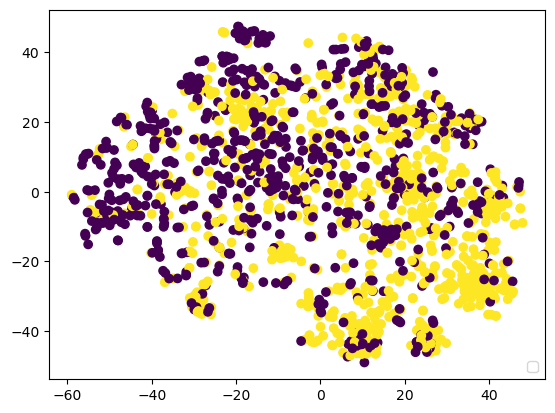

0  
1.0    828
0.0    740
Name: count, dtype: int64
Training Accuracy: 0.9585459183673469
Training MCC Score: 0.9168550881556691
Training F1 Score: 0.9583800054148462
Training AUC VALUE: 0.9931404230317274
Training kappa Score: 0.9167641236385968
Training Precision: 0.9547079856972587
Training Recall: 0.967391304347826
Training Sensitivity: 0.967391304347826
Training Specificity: 0.9486486486486486
Training CCR: 0.9585459183673469
Training PPV: 0.9547079856972587


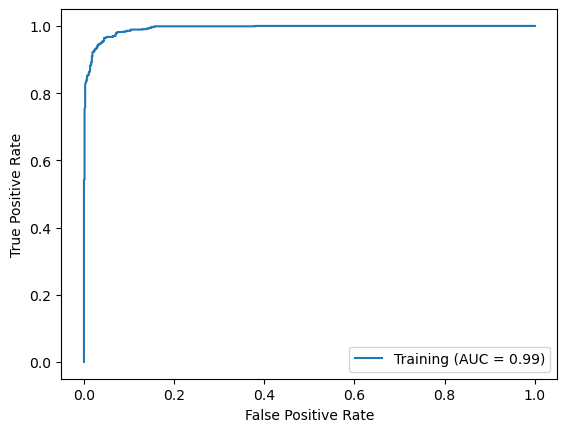

Testing Accuracy: 0.703030303030303
Testing MCC Score: 0.3953632876715829
Testing F1 Score: 0.69765528589058
Testing AUC VALUE: 0.7482078853046595
Testing kappa Score: 0.39533318375588955
Testing Precision: 0.7340425531914894
Testing Recall: 0.7419354838709677
Testing Sensitivity: 0.7419354838709677
Testing Specificity: 0.6527777777777778
Testing CCR: 0.703030303030303
Testing PPV: 0.7340425531914894


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


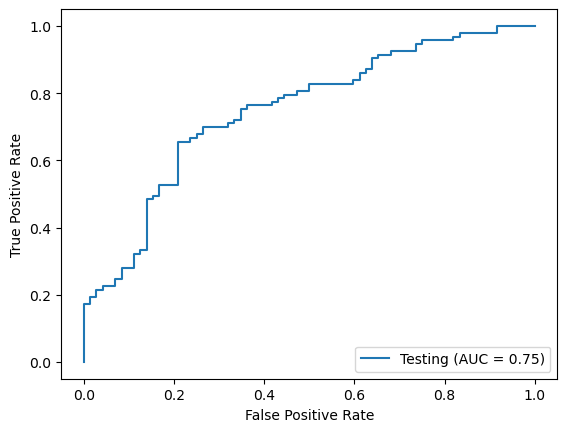

2024-11-05 00:07:56,371:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:07:56,373:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:07:56,373:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #2


C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


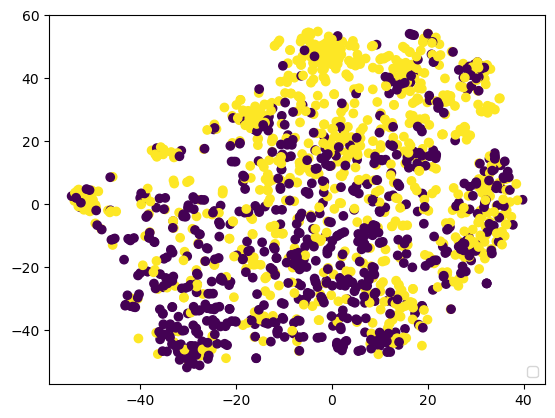

0  
1.0    829
0.0    740
Name: count, dtype: int64
Training Accuracy: 0.9592096876991715
Training MCC Score: 0.9181566157479262
Training F1 Score: 0.9590531864919881
Training AUC VALUE: 0.9939898281876569
Training kappa Score: 0.9181085101385735
Training Precision: 0.956989247311828
Training Recall: 0.9662243667068757
Training Sensitivity: 0.9662243667068757
Training Specificity: 0.9513513513513514
Training CCR: 0.9592096876991715
Training PPV: 0.956989247311828


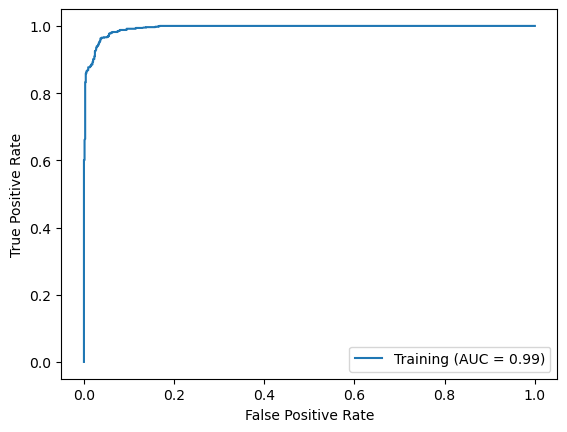

Testing Accuracy: 0.7212121212121212
Testing MCC Score: 0.43224416247112807
Testing F1 Score: 0.7156877434821696
Testing AUC VALUE: 0.7861822513400833
Testing kappa Score: 0.4317160826594789
Testing Precision: 0.7395833333333334
Testing Recall: 0.7717391304347826
Testing Sensitivity: 0.7717391304347826
Testing Specificity: 0.6575342465753424
Testing CCR: 0.7212121212121212
Testing PPV: 0.7395833333333334


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


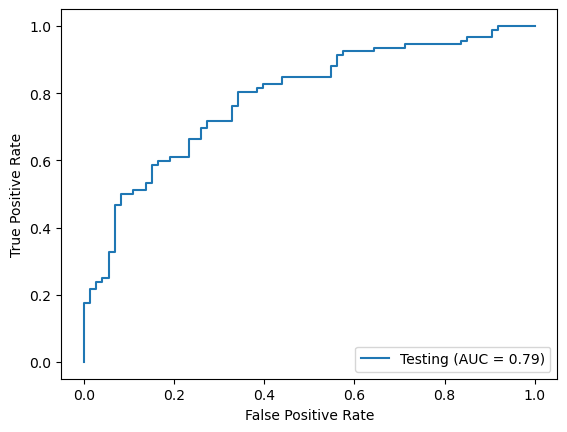

2024-11-05 00:08:01,040:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:08:01,041:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:08:01,042:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #3


C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


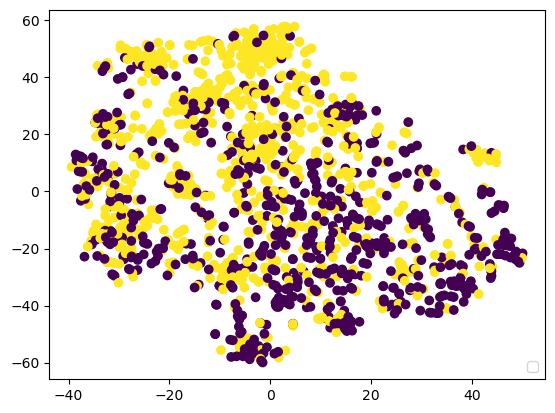

0  
1.0    829
0.0    740
Name: count, dtype: int64
Training Accuracy: 0.9521988527724665
Training MCC Score: 0.9041849016031883
Training F1 Score: 0.9519796778241397
Training AUC VALUE: 0.9920304502331041
Training kappa Score: 0.9039706807615755
Training Precision: 0.9456264775413712
Training Recall: 0.9650180940892642
Training Sensitivity: 0.9650180940892642
Training Specificity: 0.9378378378378378
Training CCR: 0.9521988527724665
Training PPV: 0.9456264775413712


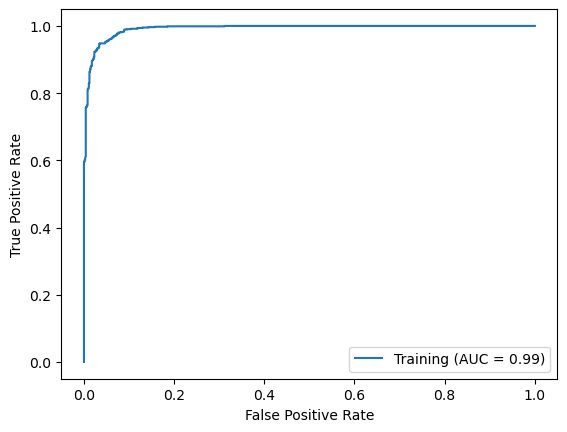

Testing Accuracy: 0.703030303030303
Testing MCC Score: 0.3972566301746008
Testing F1 Score: 0.6986020503261883
Testing AUC VALUE: 0.7364502680166767
Testing kappa Score: 0.3972265712368598
Testing Precision: 0.7311827956989247
Testing Recall: 0.7391304347826086
Testing Sensitivity: 0.7391304347826086
Testing Specificity: 0.6575342465753424
Testing CCR: 0.703030303030303
Testing PPV: 0.7311827956989247


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


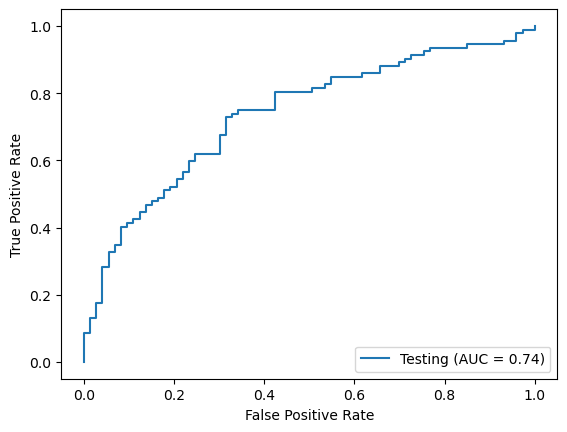

2024-11-05 00:08:05,609:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:08:05,610:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:08:05,611:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #4


C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


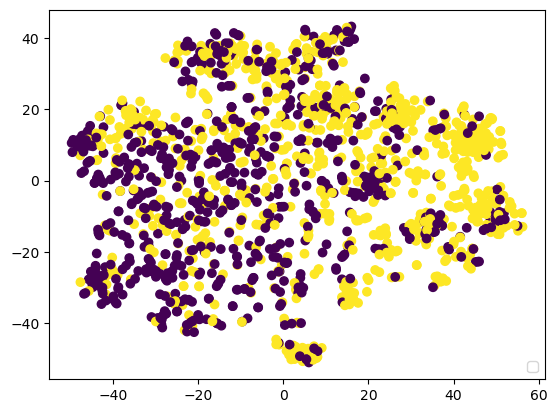

0  
1.0    829
0.0    740
Name: count, dtype: int64
Training Accuracy: 0.964308476736775
Training MCC Score: 0.9283865288690379
Training F1 Score: 0.964193264434519
Training AUC VALUE: 0.9941487627555179
Training kappa Score: 0.9283865288690379
Training Precision: 0.9662243667068757
Training Recall: 0.9662243667068757
Training Sensitivity: 0.9662243667068757
Training Specificity: 0.9621621621621622
Training CCR: 0.964308476736775
Training PPV: 0.9662243667068757


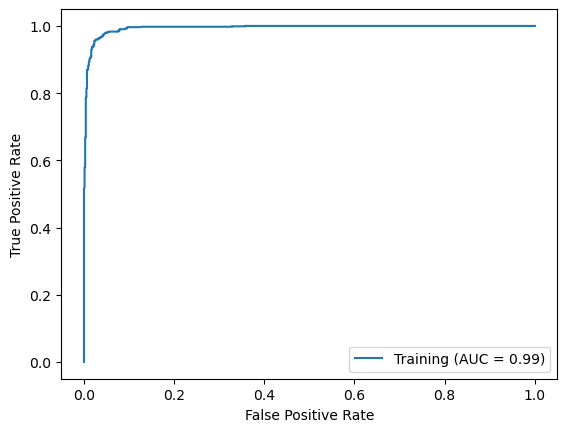

Testing Accuracy: 0.7272727272727273
Testing MCC Score: 0.4542851864803675
Testing F1 Score: 0.7258225324027916
Testing AUC VALUE: 0.8144729005360333
Testing kappa Score: 0.45263545890158496
Testing Precision: 0.7764705882352941
Testing Recall: 0.717391304347826
Testing Sensitivity: 0.717391304347826
Testing Specificity: 0.7397260273972602
Testing CCR: 0.7272727272727273
Testing PPV: 0.7764705882352941


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


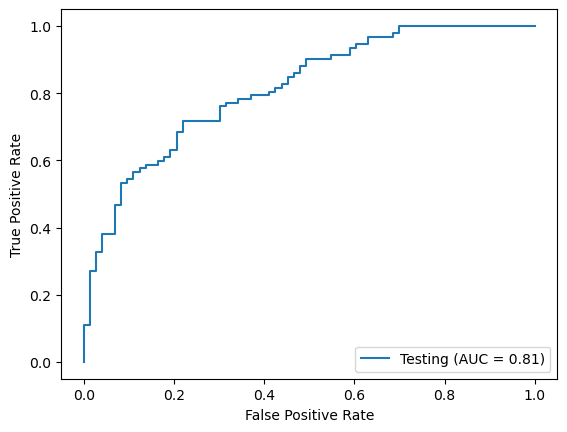

2024-11-05 00:08:10,106:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:08:10,107:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:08:10,108:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #5


C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


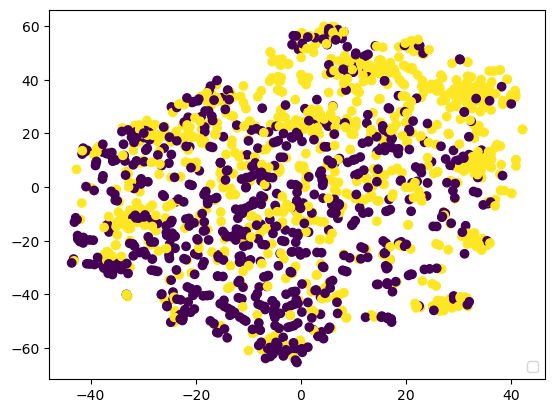

0  
1.0    829
0.0    740
Name: count, dtype: int64
Training Accuracy: 0.9572976418100702
Training MCC Score: 0.9144720670571735
Training F1 Score: 0.957094351774644
Training AUC VALUE: 0.9924502005020703
Training kappa Score: 0.9142013452179144
Training Precision: 0.9492924528301887
Training Recall: 0.971049457177322
Training Sensitivity: 0.971049457177322
Training Specificity: 0.9418918918918919
Training CCR: 0.9572976418100702
Training PPV: 0.9492924528301887


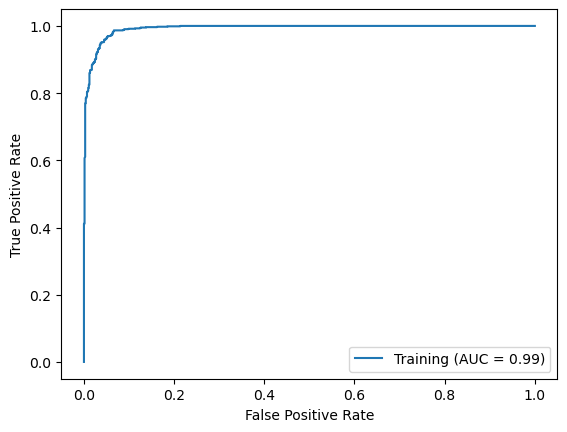

Testing Accuracy: 0.696969696969697
Testing MCC Score: 0.38764418824044455
Testing F1 Score: 0.6937184437184437
Testing AUC VALUE: 0.7674210839785587
Testing kappa Score: 0.38752783964365256
Testing Precision: 0.7333333333333333
Testing Recall: 0.717391304347826
Testing Sensitivity: 0.717391304347826
Testing Specificity: 0.6712328767123288
Testing CCR: 0.696969696969697
Testing PPV: 0.7333333333333333


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


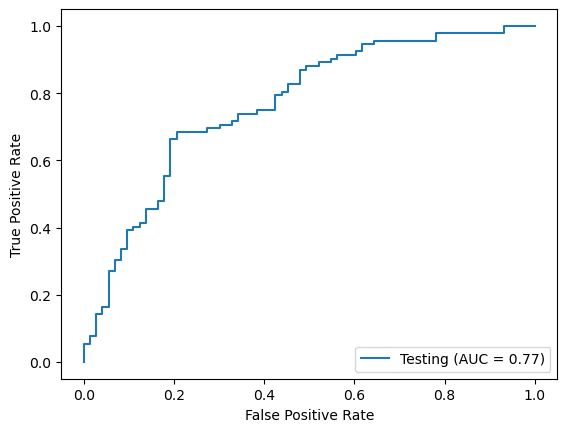

2024-11-05 00:08:14,652:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:08:14,653:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:08:14,654:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #6


C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


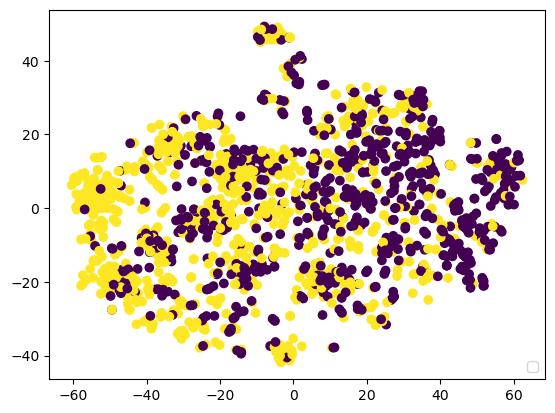

0  
1.0    829
0.0    740
Name: count, dtype: int64
Training Accuracy: 0.9630337794773741
Training MCC Score: 0.9258238860361525
Training F1 Score: 0.9628977598893644
Training AUC VALUE: 0.9947665699475109
Training kappa Score: 0.9257966088980142
Training Precision: 0.9616766467065868
Training Recall: 0.9686369119420989
Training Sensitivity: 0.9686369119420989
Training Specificity: 0.9567567567567568
Training CCR: 0.9630337794773741
Training PPV: 0.9616766467065868


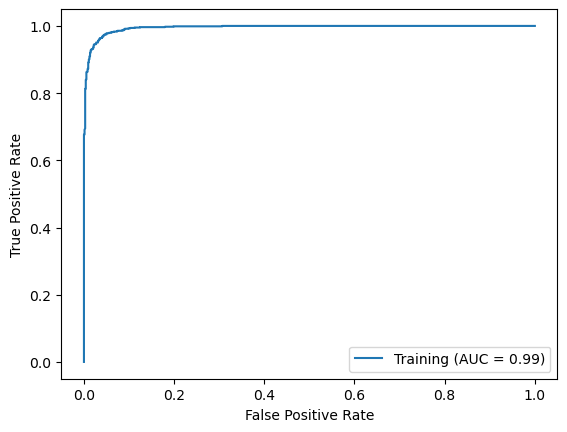

Testing Accuracy: 0.6890243902439024
Testing MCC Score: 0.36456732777241085
Testing F1 Score: 0.6816261276692932
Testing AUC VALUE: 0.7037288647342995
Testing kappa Score: 0.3638576209309401
Testing Precision: 0.711340206185567
Testing Recall: 0.75
Testing Sensitivity: 0.75
Testing Specificity: 0.6111111111111112
Testing CCR: 0.6890243902439024
Testing PPV: 0.711340206185567


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


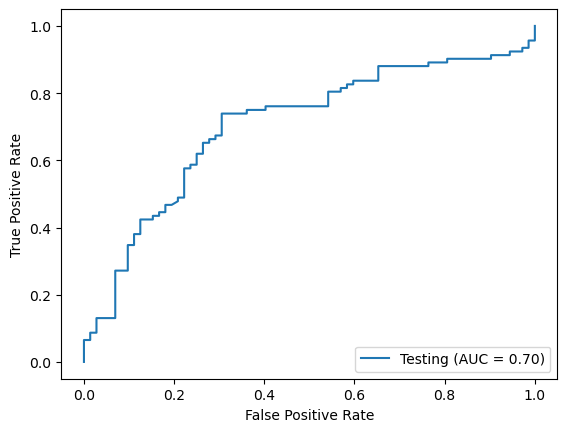

2024-11-05 00:08:19,431:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:08:19,432:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:08:19,433:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #7


C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


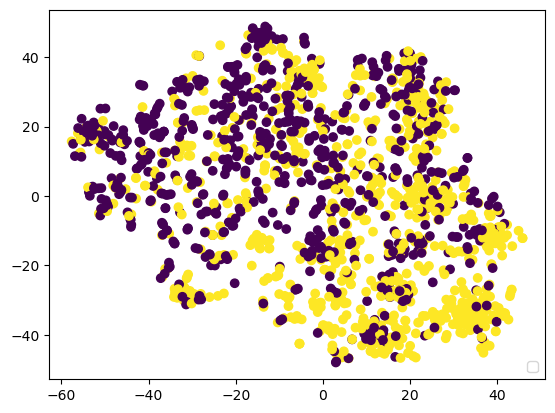

0  
1.0    829
0.0    740
Name: count, dtype: int64
Training Accuracy: 0.952836201402167
Training MCC Score: 0.9053679131483715
Training F1 Score: 0.9526839565741858
Training AUC VALUE: 0.9930712678903271
Training kappa Score: 0.9053679131483715
Training Precision: 0.9553679131483716
Training Recall: 0.9553679131483716
Training Sensitivity: 0.9553679131483716
Training Specificity: 0.95
Training CCR: 0.952836201402167
Training PPV: 0.9553679131483716


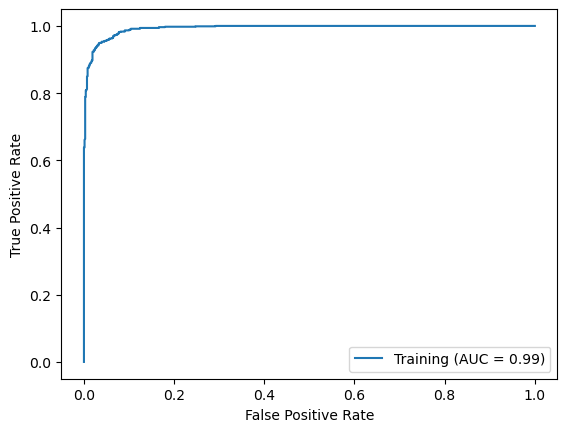

Testing Accuracy: 0.7012195121951219
Testing MCC Score: 0.39642369848420667
Testing F1 Score: 0.6979742173112339
Testing AUC VALUE: 0.7676630434782609
Testing kappa Score: 0.39615269011121124
Testing Precision: 0.7415730337078652
Testing Recall: 0.717391304347826
Testing Sensitivity: 0.717391304347826
Testing Specificity: 0.6805555555555556
Testing CCR: 0.7012195121951219
Testing PPV: 0.7415730337078652


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


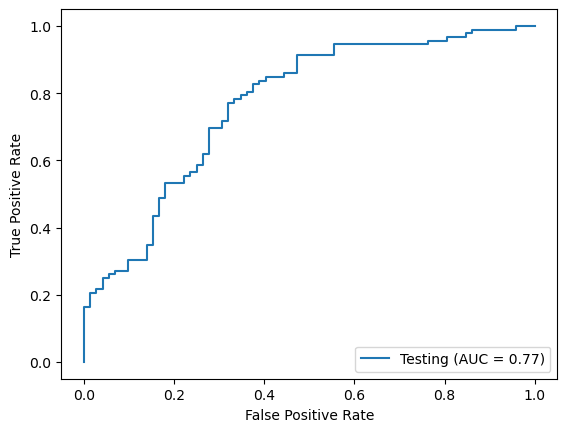

2024-11-05 00:08:23,777:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:08:23,779:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:08:23,780:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #8


C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


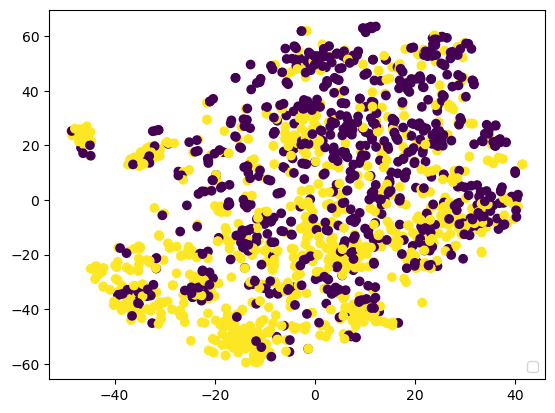

0  
1.0    829
0.0    740
Name: count, dtype: int64
Training Accuracy: 0.9636711281070746
Training MCC Score: 0.9271002352248854
Training F1 Score: 0.9635402631552127
Training AUC VALUE: 0.994587259153001
Training kappa Score: 0.9270812694918363
Training Precision: 0.9628297362110312
Training Recall: 0.9686369119420989
Training Sensitivity: 0.9686369119420989
Training Specificity: 0.9581081081081081
Training CCR: 0.9636711281070746
Training PPV: 0.9628297362110312


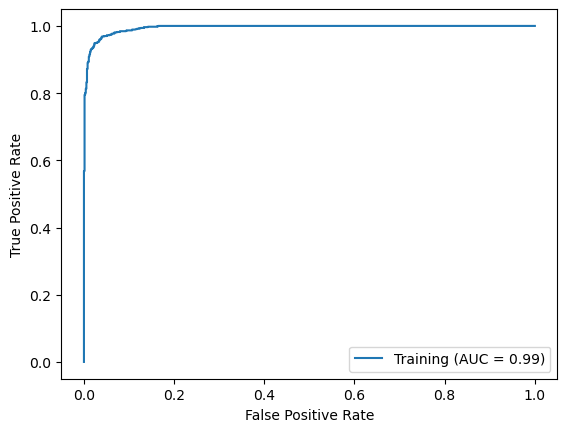

Testing Accuracy: 0.6829268292682927
Testing MCC Score: 0.3630435097414673
Testing F1 Score: 0.6805992509363297
Testing AUC VALUE: 0.7010869565217391
Testing kappa Score: 0.3620586475164572
Testing Precision: 0.7325581395348837
Testing Recall: 0.6847826086956522
Testing Sensitivity: 0.6847826086956522
Testing Specificity: 0.6805555555555556
Testing CCR: 0.6829268292682927
Testing PPV: 0.7325581395348837


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


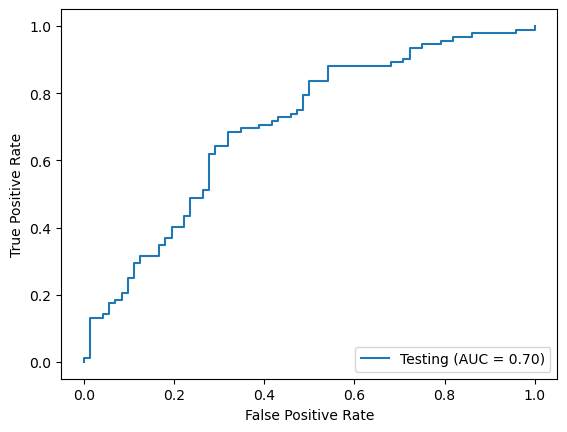

2024-11-05 00:08:28,421:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:08:28,423:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:08:28,423:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #9


C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


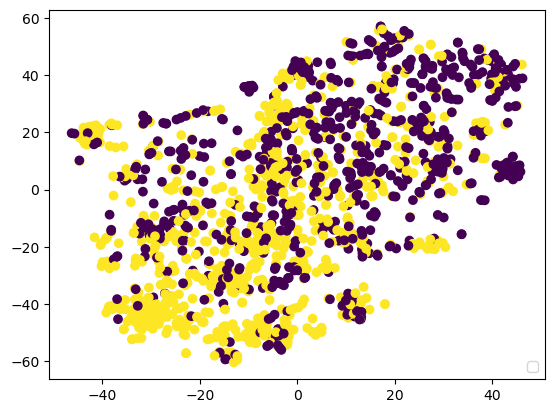

0  
1.0    829
0.0    740
Name: count, dtype: int64
Training Accuracy: 0.9655831739961759
Training MCC Score: 0.9309441528380008
Training F1 Score: 0.9654720764190005
Training AUC VALUE: 0.9947396733283344
Training kappa Score: 0.9309441528380008
Training Precision: 0.9674306393244874
Training Recall: 0.9674306393244874
Training Sensitivity: 0.9674306393244874
Training Specificity: 0.9635135135135136
Training CCR: 0.9655831739961759
Training PPV: 0.9674306393244874


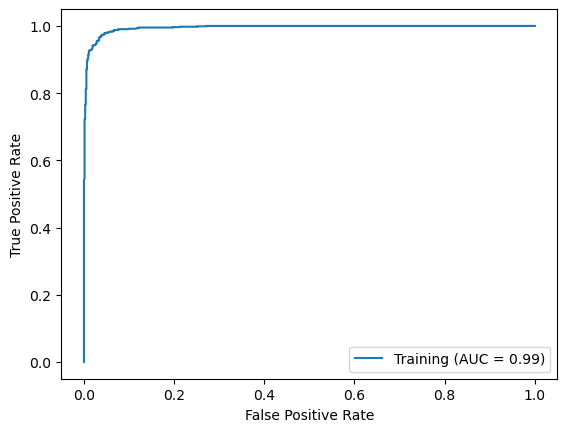

Testing Accuracy: 0.6951219512195121
Testing MCC Score: 0.37536264671100894
Testing F1 Score: 0.6859681372549018
Testing AUC VALUE: 0.7650966183574879
Testing kappa Score: 0.37347188264058684
Testing Precision: 0.71
Testing Recall: 0.7717391304347826
Testing Sensitivity: 0.7717391304347826
Testing Specificity: 0.5972222222222222
Testing CCR: 0.6951219512195121
Testing PPV: 0.71


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


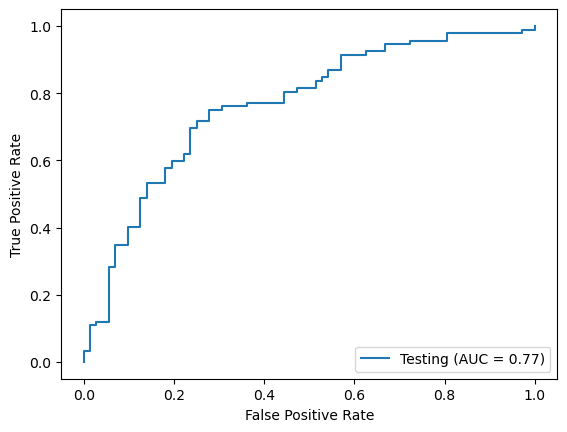

2024-11-05 00:08:32,802:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-05 00:08:32,803:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-05 00:08:32,804:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #10


C:\Users\DELL\AppData\Local\Temp\ipykernel_15460\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


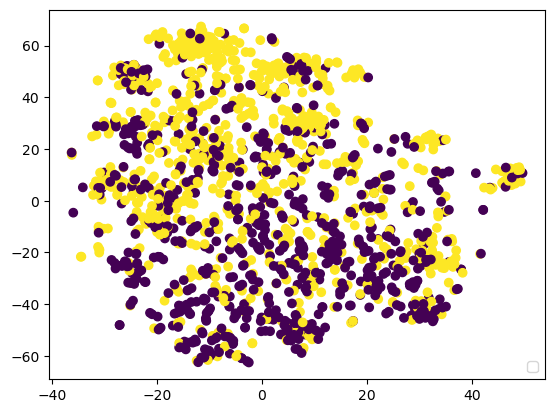

0  
1.0    829
0.0    740
Name: count, dtype: int64
Training Accuracy: 0.958572339069471
Training MCC Score: 0.9169918450752141
Training F1 Score: 0.9583823874475877
Training AUC VALUE: 0.9928495745443877
Training kappa Score: 0.9167745899933655
Training Precision: 0.9515366430260047
Training Recall: 0.971049457177322
Training Sensitivity: 0.971049457177322
Training Specificity: 0.9445945945945946
Training CCR: 0.958572339069471
Training PPV: 0.9515366430260047


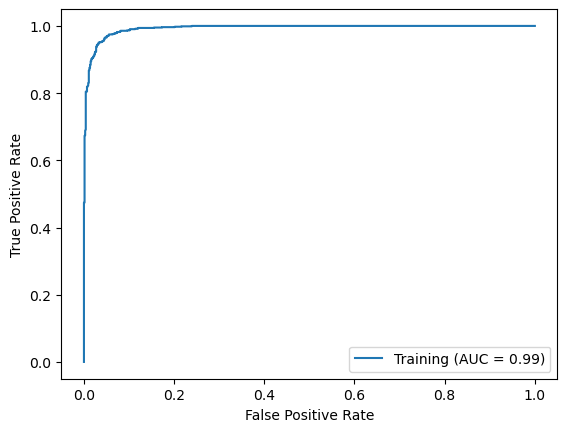

Testing Accuracy: 0.6951219512195121
Testing MCC Score: 0.37643980171551994
Testing F1 Score: 0.687261632341724
Testing AUC VALUE: 0.7795893719806763
Testing kappa Score: 0.37538086532602066
Testing Precision: 0.7142857142857143
Testing Recall: 0.7608695652173914
Testing Sensitivity: 0.7608695652173914
Testing Specificity: 0.6111111111111112
Testing CCR: 0.6951219512195121
Testing PPV: 0.7142857142857143


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


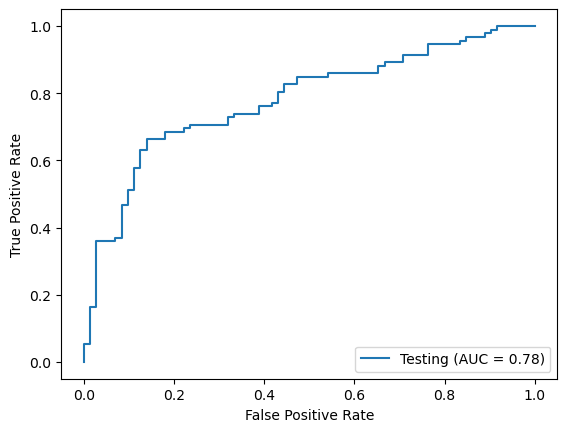

"\n    all_predictions = []\n    all_probabilities = []\n    all_labels = []\n    # 拼接训练集和测试集的预测结果和真实标签\n    all_predictions.extend(y_train_pred)\n    all_probabilities.extend(y_train_prob)\n    all_labels.extend(Final_Ytrain)\n    \n    all_predictions.extend(y_test_pred)\n    all_probabilities.extend(y_test_prob)\n    all_labels.extend(Test_y)\n\n    # 计算总的评价指标\n    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))\n"

In [50]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

Train_Fold_outs_1 = []
Test_Fold_outs_1 = []
models_1 = []

# 用于存储训练和测试集的预测结果和标签

total_metrics = []

# 定义 10 折交叉验证
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 获取特征和标签
X = Data[f_list].values  # 替换 Data 为你的数据集，f_list 为你的特征列表
y = Data['status'].values

Parameters = pd.DataFrame.from_dict(Best_params).iloc[5].to_dict()
print(Parameters)
# 10 折交叉验证
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f'Fold #{fold+1}')
    
    # 获取训练集和测试集
    Train_x, Test_x = X[train_index], X[test_index]
    Train_y, Test_y = y[train_index], y[test_index]
    
    # Upsampling
    Final_Xtrain, Final_Ytrain = Smote(pd.DataFrame(Train_x, columns=f_list), pd.Series(Train_y),0.5)
    print(Final_Ytrain.value_counts())
    Final_Ytrain = Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype=np.float64)
    Test_x_filtered = pd.DataFrame(Test_x, dtype=np.float64)

    # 使用 KNeighborsClassifier
    rf = RandomForestClassifier(max_features=Parameters['max_features'],
                        max_depth=Parameters['max_depth'],
                        min_samples_split=Parameters['min_samples_split'],
                        min_samples_leaf=Parameters['min_samples_leaf'],
                        bootstrap=Parameters['bootstrap'],
                        n_estimators=Parameters['n_estimators'])

    
    # 拟合模型
    rf.fit(Final_Xtrain, Final_Ytrain)
    models_1.append(rf)
    
    # 训练集预测
    y_train_pred = rf.predict(Final_Xtrain)
    y_train_prob = rf.predict_proba(Final_Xtrain)[:, 1]
    Train_Fold_outs_1.append(Scoring_metrices(y_train_pred, y_train_prob, Final_Ytrain, 'Training'))

    # 测试集预测
    y_test_pred = rf.predict(Test_x_filtered)
    y_test_prob = rf.predict_proba(Test_x_filtered)[:, 1]
    Test_Fold_outs_1.append(Scoring_metrices(y_test_pred, y_test_prob, Test_y, 'Testing'))
'''
    all_predictions = []
    all_probabilities = []
    all_labels = []
    # 拼接训练集和测试集的预测结果和真实标签
    all_predictions.extend(y_train_pred)
    all_probabilities.extend(y_train_prob)
    all_labels.extend(Final_Ytrain)
    
    all_predictions.extend(y_test_pred)
    all_probabilities.extend(y_test_prob)
    all_labels.extend(Test_y)

    # 计算总的评价指标
    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))
'''

In [51]:
#Analyse the training metrics sorted by descending Training Accuracy
pd.DataFrame.from_dict(Test_Fold_outs_1).sort_values(by=['Testing kappa Score:'],ascending = False)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
3,0.727273,0.454285,0.725823,0.814473,0.452635,0.776471,0.717391,0.717391,0.739726,0.727273,0.776471
1,0.721212,0.432244,0.715688,0.786182,0.431716,0.739583,0.771739,0.771739,0.657534,0.721212,0.739583
2,0.703030,0.397257,0.698602,0.736450,0.397227,0.731183,0.739130,0.739130,0.657534,0.703030,0.731183
6,0.701220,0.396424,0.697974,0.767663,0.396153,0.741573,0.717391,0.717391,0.680556,0.701220,0.741573
0,0.703030,0.395363,0.697655,0.748208,0.395333,0.734043,0.741935,0.741935,0.652778,0.703030,0.734043
4,0.696970,0.387644,0.693718,0.767421,0.387528,0.733333,0.717391,0.717391,0.671233,0.696970,0.733333
9,0.695122,0.376440,0.687262,0.779589,0.375381,0.714286,0.760870,0.760870,0.611111,0.695122,0.714286
8,0.695122,0.375363,0.685968,0.765097,0.373472,0.710000,0.771739,0.771739,0.597222,0.695122,0.710000
5,0.689024,0.364567,0.681626,0.703729,0.363858,0.711340,0.750000,0.750000,0.611111,0.689024,0.711340
7,0.682927,0.363044,0.680599,0.701087,0.362059,0.732558,0.684783,0.684783,0.680556,0.682927,0.732558


<Axes: >

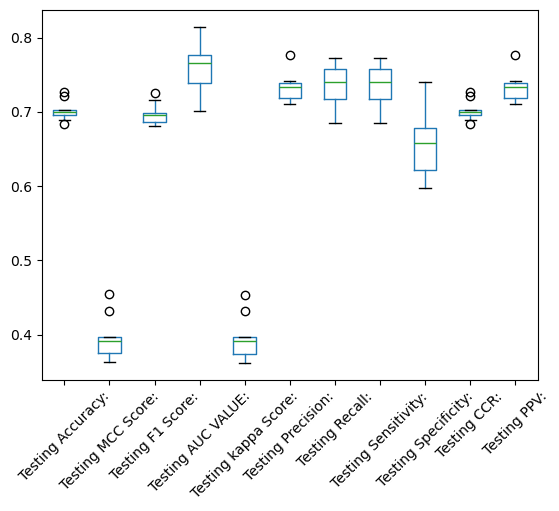

In [52]:
#To visualize the stability of the tuned model with each fold
(pd.DataFrame(Test_Fold_outs_1)).boxplot(grid=False,rot=45)

In [53]:
pd.DataFrame(Test_Fold_outs_1)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
0,0.703030,0.395363,0.697655,0.748208,0.395333,0.734043,0.741935,0.741935,0.652778,0.703030,0.734043
1,0.721212,0.432244,0.715688,0.786182,0.431716,0.739583,0.771739,0.771739,0.657534,0.721212,0.739583
2,0.703030,0.397257,0.698602,0.736450,0.397227,0.731183,0.739130,0.739130,0.657534,0.703030,0.731183
3,0.727273,0.454285,0.725823,0.814473,0.452635,0.776471,0.717391,0.717391,0.739726,0.727273,0.776471
4,0.696970,0.387644,0.693718,0.767421,0.387528,0.733333,0.717391,0.717391,0.671233,0.696970,0.733333
5,0.689024,0.364567,0.681626,0.703729,0.363858,0.711340,0.750000,0.750000,0.611111,0.689024,0.711340
6,0.701220,0.396424,0.697974,0.767663,0.396153,0.741573,0.717391,0.717391,0.680556,0.701220,0.741573
7,0.682927,0.363044,0.680599,0.701087,0.362059,0.732558,0.684783,0.684783,0.680556,0.682927,0.732558
8,0.695122,0.375363,0.685968,0.765097,0.373472,0.710000,0.771739,0.771739,0.597222,0.695122,0.710000
9,0.695122,0.376440,0.687262,0.779589,0.375381,0.714286,0.760870,0.760870,0.611111,0.695122,0.714286


In [54]:
TRAIN = Data.drop(['smiles','status'],axis=1)
TRAIN

,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,A1_9,...,E5_118,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127
0,-0.100800,0.096205,-0.101666,0.013622,0.045533,0.103638,0.100818,-0.085028,-0.027932,-0.060816,...,-0.126018,0.077215,-0.060099,0.000407,0.024521,-0.008713,0.052200,0.073152,-0.119952,0.076824
1,-0.096464,0.053822,-0.087383,0.095549,-0.091416,0.096470,0.096480,-0.096477,-0.077987,-0.029744,...,-0.012364,-0.118487,-0.006075,0.104476,0.081948,-0.120817,-0.001020,-0.131218,0.095820,-0.004740
2,-0.094767,0.099285,-0.069983,0.078858,0.014583,0.099227,0.099023,-0.099302,-0.096730,0.058144,...,-0.026042,0.043367,-0.080618,0.056817,0.146075,0.018187,-0.044958,0.020963,0.084850,0.095499
3,0.082662,0.102963,0.096697,0.088996,0.102963,0.102961,0.098535,-0.102962,-0.102963,-0.087077,...,0.105257,0.040878,-0.093784,0.035378,-0.097579,0.009945,-0.008528,-0.013349,-0.078162,-0.111090
4,-0.096225,0.070796,0.064892,0.091473,-0.093061,0.077097,0.088396,-0.096911,-0.096889,0.095496,...,-0.104367,-0.055854,0.063072,0.029263,0.087089,0.052258,0.060351,-0.020115,0.083724,0.063224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1640,0.100701,0.100916,-0.074545,0.100947,0.100983,0.100974,-0.099876,-0.100985,-0.100985,-0.011020,...,-0.071526,-0.037687,-0.037889,0.077509,0.004429,-0.126974,-0.104519,-0.128836,-0.138834,0.074467
1641,-0.094284,-0.093734,-0.093366,-0.093898,-0.094284,0.082861,0.094284,-0.055373,0.065112,-0.080060,...,0.084928,-0.008070,0.049642,-0.096573,0.016450,-0.077732,0.119295,0.136613,0.142595,0.075937
1642,0.087762,0.102691,-0.080387,0.104354,0.104394,0.104216,-0.094918,-0.104398,-0.104403,-0.094400,...,0.013853,0.013931,0.066649,0.075433,0.087392,0.006906,-0.104028,-0.127244,0.015713,0.102034
1643,-0.100700,-0.096396,-0.103261,-0.039456,-0.090105,0.103162,0.103213,0.018000,0.081154,-0.102759,...,-0.118747,-0.084086,-0.101899,-0.091386,-0.104063,0.063007,0.121405,-0.042903,-0.044005,-0.042278


In [55]:
TRAIN = TRAIN[f_list] #Use features of the selected (hyperparameter tuned) model here
TRAIN

,A3_7,A3_83,A3_96,B2_70,B5_14,C1_0,C1_47,C1_54,C1_57,C1_95,...,E4_106,E4_111,E4_112,E4_116,E4_117,E4_118,E4_120,E4_122,E4_125,E5_53
0,0.011516,0.074760,-0.103263,-0.095983,0.049122,0.114675,-0.127570,-0.047225,-0.121013,0.119603,...,-0.064057,0.110072,0.091087,-0.006036,0.102261,0.105300,0.047503,0.086181,-0.100890,0.030956
1,0.097806,-0.083661,-0.100517,0.020241,-0.051123,0.113096,-0.116935,0.015399,0.089848,0.028632,...,-0.135021,0.003088,-0.078185,-0.129429,0.070241,0.136066,-0.104320,0.129967,-0.115071,-0.125696
2,0.107641,-0.107801,0.111293,0.001995,-0.066885,0.085748,-0.075824,-0.037541,-0.007628,-0.016436,...,0.009335,0.066510,0.137540,-0.048368,-0.052314,0.078827,-0.030551,-0.021361,0.011509,-0.001393
3,-0.104072,0.104047,-0.095365,0.009876,-0.059738,0.044662,-0.089071,0.109594,0.116190,-0.011709,...,-0.103649,0.104838,-0.063600,0.080693,-0.066877,-0.023390,0.108122,0.056834,0.022375,0.023485
4,0.089722,-0.008160,-0.094154,-0.022041,-0.071935,0.117001,-0.110422,-0.116092,-0.098040,0.107777,...,-0.112815,-0.070288,-0.072763,-0.111684,0.111692,0.112794,-0.073980,0.112494,-0.097193,-0.112936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1640,0.088394,-0.118968,-0.038083,0.088579,-0.043139,-0.043063,-0.081620,0.109729,0.120349,-0.109094,...,0.072011,0.033872,0.117919,0.042517,-0.095002,-0.020117,0.094476,-0.128764,0.109337,-0.079190
1641,0.093073,-0.098851,-0.083383,-0.105057,-0.030357,-0.049449,-0.088968,-0.101701,-0.103333,0.006558,...,0.074504,0.063170,0.027516,0.007124,0.035683,0.001409,-0.033484,0.075646,0.097661,-0.046335
1642,-0.113386,0.099843,-0.081330,0.143248,-0.009190,-0.039165,-0.079356,0.076378,0.091437,-0.053883,...,-0.091250,-0.031848,0.086350,0.121969,0.105882,0.067505,0.127195,0.116388,0.026568,-0.029858
1643,0.098679,0.036759,-0.098598,-0.114260,-0.041565,0.110524,-0.116466,0.049182,-0.112966,0.116413,...,0.104902,0.109516,0.104850,-0.103147,-0.102760,0.105572,0.056369,-0.105530,0.070392,-0.110773


In [56]:
Y = Data['status']

In [57]:
#Fitting the model on whole data
fitted = models_1[3].fit(TRAIN,Y)
fitted

RandomForestClassifier(max_depth=10.0, max_features=0.5, min_samples_leaf=4,
                       min_samples_split=6, n_estimators=45)

In [58]:
#Save the final model
joblib.dump(fitted, 'AID_1259411_RF.pkl')

['AID_1259411_RF.pkl']

In [59]:
import joblib
import pandas as pd

class model_AID_1259411:
    def __init__(self, test):        
        self.test = test

    def extract_feature(self, data):        
        # 读取特征文件
        F_names = pd.read_csv('AID_1259411_features.csv')
        features = F_names.iloc[:, 0].tolist()
        return data[features]

    def get_labels(self, pred_test):
        # 根据概率预测类别
        test_pred = []
        for i in range(pred_test.shape[0]):
            if pred_test[i][0] > pred_test[i][1]:  # 类别 0 概率更大
                test_pred.append(0)
            else:
                test_pred.append(1)  # 类别 1 概率更大
        return test_pred

    def test_model(self):
        # 提取特征并加载本地的 KNN 模型进行预测
        test = self.test
        test_filtered = self.extract_feature(test.drop(['smiles'], axis=1))
        
        # 本地加载 KNN 模型
        model = joblib.load('AID_1259411_RF.pkl')
        
        # 使用模型进行预测
        probs = model.predict_proba(test_filtered)
        
        # 获取预测类别
        preds = self.get_labels(probs)
        
        return probs, preds


def AID_1259411(smi_list):
    Feature_data = pd.DataFrame()
    Feature_data['smiles'] = smi_list

    Sig_Carcin = Feature_Signaturizer(smi_list)
    
    # 保留删除前的索引
    original_index = Sig_Carcin.index
    
    # 删除缺失值的行
    Sig_Carcin_clean = Sig_Carcin.dropna()

    # 使用清理过的数据进行模型测试
    m4 = model_AID_1259411(Sig_Carcin_clean)  # 假设这里的模型函数改为 model_apoptosis
    probs, preds = m4.test_model()

    # 创建一个与原始索引匹配的结果数组
    Feature_data['AID_1259411_0'] = None
    Feature_data['AID_1259411_1'] = None
    Feature_data['AID_1259411_preds'] = None

    # 填充有效的预测结果
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1259411_0'] = probs[:, 0]
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1259411_1'] = probs[:, 1]
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1259411_preds'] = preds

    return Feature_data


In [19]:
# 指定当前的工作文件夹
import os
# 此处为google drive中的文件路径,drive为之前指定的工作根目录，要加上
os.chdir("C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao")
#load preprocessed feature file here
data = pd.read_csv(r'MKETn_Training_Data.csv') ### features in columns,molecules in rows
data

,SMILES,Name,CID,InChI,IUPAC,Status,Source
0,[As],Arsenic,5359596.0,1S/As,arsenic,1,CCRIS
1,[Be],Beryllium,5460467.0,1S/Be,beryllium,1,CCRIS
2,[Be]=O,Beryllium oxide,14775.0,1S/Be.O,oxoberyllium,1,CCRIS
3,[Be+2].[OH-].[OH-],Dihydroxyberyllium,25879.0,1S/Be.2H2O/h;2*1H2/q+2;;/p-2,beryllium;dihydroxide,1,CCRIS
4,[C-]#[Si+],Silicon carbide,9863.0,1S/CSi/c1-2,methanidylidynesilanylium,1,CCRIS
...,...,...,...,...,...,...,...
461,P#[Ga],Gallium phosphide,82901.0,1S/Ga.P,gallanylidynephosphane,0,CCRIS
462,S=[Cd],Cadmium sulfide,14783.0,1S/Cd.S,sulfanylidenecadmium,1,CCRIS
463,S=[Ni],Nickel sulfide,28094.0,1S/Ni.S,sulfanylidenenickel,1,CCRIS
464,S=P(N1CC1)(N1CC1)N1CCOCC1,Morzid,62432.0,"1S/C8H16N3OPS/c14-13(9-1-2-9,10-3-4-10)11-5-7-...",bis(aziridin-1-yl)-morpholin-4-yl-sulfanyliden...,1,CCRIS
